# AECD PS standard-material calibrated mean-spectrum clinical evaluation

이 notebook은 현재 임상성능 분석의 reader-facing experiment surface입니다. 분석 구현은 scripts/analysis/aecd_api_model_mean_spectrum_clinical_performance.py에 두고, 이 notebook에서 실제 API/DB 데이터로 전체 실행 결과와 figure를 확인합니다.

## tl;dr

- Data lineage: AECD REST API clinical spectra plus read-only PostgreSQL PS standard-material calibration records
- Clinical model input: each subject's mean of repeat-QC-passed, PS-aligned spectra; no post-mean spectral preprocessing
- Primary comparison: direct raw mean-spectrum stacking versus STK-V2 stacking on the same canonical subject-level input
- Threshold policy: balanced-accuracy threshold selected inside each outer-training fold using inner meta-level OOF predictions; fixed threshold 0.4 is reported as a comparison
- The executed cells below regenerate the current cohort, model metrics, CSV outputs, and publication-ready figures

Cancer Screening performance here is internal to this hospital/cohort structure and is not cross-hospital generalization.

## Context & Methods

### Key assumptions

- Clinical urine spectra are not searched for a calibration peak.
- PS reference peaks and daily global shifts come from passing records in measurement.calibrations.
- The stored shift is observed peak minus reference peak; the applied axis correction is x_corrected = x_observed - global_shift_cm1.
- Current clinical runs have NULL calibration_id, so matching uses measurement date plus instrument name and fails on missing or duplicate records.
- Repeat QC is within subject before averaging. Noise is the per-wavenumber sample SD of QC-passed repeat residuals.
- Peak candidates use prominence at least 3 times repeat residual SD divided by the square root of the number of QC-passed repeats for mean-spectrum precision. Repeat-level and independent-mean SNR are retained for descriptive validation only.
- The Cancer Screening result may contain hospital, collection, or batch confounding; it is not cross-hospital generalization.

### Models and preprocessing distinction

Both models start from the same upstream canonical input: Polystyrene (PS) standard-material axis correction, within-subject repeat QC, and the mean of the QC-passed aligned repeats.

The direct raw mean-spectrum model applies no additional post-mean spectral transformation. Its base estimators are scaled logistic regression, XGBoost, random forest, and stronger-L2 logistic regression; an elastic-net logistic regression combines their subject-level predictions in nested GroupKFold.

STK-V2 does not use an identical preprocessing path. It consumes the same canonical subject means, then applies its own defined view construction: 400–2200 cm-1 crop, fixed-grid interpolation, Savitzky–Golay/baseline/SNV processing, first and second derivative channels, and fixed peak features. Those views feed ten base models and an elastic-net logistic meta learner. Therefore the comparison changes both the post-mean feature representation and the stacking architecture, while keeping the upstream cohort and subject-level input fixed.

### Threshold and multiclass policy

For binary Cancer Screening, the primary threshold is selected without using the outer test labels: within every outer fold, inner meta-level OOF probabilities from the outer-training subjects maximize balanced accuracy, and that fold-specific threshold is applied once to the outer test subjects. Fixed threshold 0.4 remains a transparent comparison.

The 3-class evaluation preserves the three clinical labels control, prostate disease control, and prostate. It uses argmax over the OOF class probabilities and reports macro/weighted one-vs-rest ROC-AUC, balanced accuracy, macro F1, per-class sensitivity, specificity, and a confusion matrix with counts plus true-class row percentages.

## Setup

VSCode에서 `/home/user/anaconda3/bin/python` kernel을 선택합니다. 이 cell은 `.env`와 `.env.aecd-api`의 환경변수를 읽되 secret 값은 출력하지 않습니다. 다른 실행 환경에서는 `AECD_DB_HOST`를 지정할 수 있습니다.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

REPO_ROOT = Path.cwd()
for candidate in (REPO_ROOT, *REPO_ROOT.parents):
    if (candidate / "scripts/analysis/aecd_api_model_mean_spectrum_clinical_performance.py").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("SERS-AI repository root was not found from the notebook directory.")


def load_environment_file(path: Path) -> None:
    if not path.exists():
        return
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        os.environ.setdefault(key.strip(), value.strip().strip(chr(39) + chr(34)))


load_environment_file(REPO_ROOT / ".env")
load_environment_file(REPO_ROOT / ".env.aecd-api")
os.environ.setdefault("AECD_API_BASE_URL", "http://127.0.0.1:8000")
os.environ.setdefault(
    "AECD_MEAN_SPECTRUM_OUTDIR",
    str(REPO_ROOT / "notebooks/aecd_api_model_mean_spectrum_outputs"),
)
os.environ["PGHOST"] = os.environ.get("AECD_DB_HOST", "172.18.160.1")
missing_environment = [
    name for name in ("AECD_API_KEY", "PGPASSWORD") if not os.environ.get(name)
]
if missing_environment:
    raise RuntimeError(
        "Missing environment variables: " + ", ".join(missing_environment)
    )

SCRIPT_DIR = REPO_ROOT / "scripts/analysis"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import aecd_api_model_mean_spectrum_clinical_performance as analysis

OUTPUT_DIR = Path(os.environ["AECD_MEAN_SPECTRUM_OUTDIR"])
FIGURE_DIR = OUTPUT_DIR / "figures"
print({
    "repository": str(REPO_ROOT),
    "api": os.environ["AECD_API_BASE_URL"],
    "database": f"{os.environ.get('PGUSER', 'postgres')}@{os.environ['PGHOST']}/{os.environ.get('PGDATABASE', 'aecd_platform')}",
    "output": str(OUTPUT_DIR),
})

{'repository': '/home/user/SERS-AI', 'api': 'http://127.0.0.1:8000', 'database': 'postgres@172.18.160.1/aecd_platform', 'output': '/home/user/SERS-AI/notebooks/aecd_api_model_mean_spectrum_outputs'}


## Run the canonical experiment

### 1. API → DB calibration → QC → model → export

In [2]:
analysis.main()

  [outer 1] AUC=0.9048 balanced_acc=0.7302


  [outer 2] AUC=0.7937 balanced_acc=0.7103


  [outer 3] AUC=0.6825 balanced_acc=0.5952


  [outer 4] AUC=0.4732 balanced_acc=0.5804


  [outer 5] AUC=0.5804 balanced_acc=0.4643


=== Average representative spectrum clinical evaluation ===
[data] subjects=113 repeats=13673 X=(113, 934)
[QC] passed=12939/13673 (94.63%)
[clinical] overall OOF AUC=0.6698 balanced_accuracy=0.6228
[threshold] outer-train optimized median=0.4545 range=0.3541-0.5121
[output] /home/user/SERS-AI/notebooks/aecd_api_model_mean_spectrum_outputs


## Data lineage and standard-material calibration

### 2. Source, cohort, and daily PS correction

In [3]:
metadata = json.loads((OUTPUT_DIR / "run_metadata.json").read_text(encoding="utf-8"))
cohort_summary = pd.read_csv(OUTPUT_DIR / "api_cohort_summary.csv")
calibration_rows = pd.read_csv(OUTPUT_DIR / "calibration_shift_values.csv")
calibration_summary = pd.read_csv(OUTPUT_DIR / "wavenumber_calibration_summary.csv")

print({
    "api_health": metadata["data_source"]["api_health"],
    "api_spectra": metadata["data_source"]["spectrum_total_reported"],
    "database": metadata["standard_material_calibration"]["database"],
    "standard_material": metadata["standard_material_calibration"]["standard_material"],
    "reference_peaks_cm1": metadata["standard_material_calibration"]["reference_peaks_cm1"],
})
display(cohort_summary)
display(calibration_summary)
display(
    calibration_rows
    .groupby(
        ["calibration_date", "instrument_name", "standard_material"],
        as_index=False,
    )
    .agg(
        spectra=("measurement_id", "size"),
        global_shift_observed_minus_reference_cm1=(
            "global_shift_observed_minus_reference_cm1", "first"
        ),
        applied_axis_correction_cm1=("applied_axis_correction_cm1", "first"),
    )
)

{'api_health': {'status': 'ok', 'database': 'aecd_platform'}, 'api_spectra': 13673, 'database': 'aecd_platform', 'standard_material': 'Polystyrene (PS)', 'reference_peaks_cm1': [621.3, 794.8, 1001.2, 1032.0, 1157.4, 1327.1, 1448.6, 1602.8]}


,site_code,cohort_group,cancer_type,study_cancer_type,diagnosed_cancer_type,case_status,subjects,samples,spectra
0,smcxd07,control,NaN,NaN,NaN,NaN,21,21,2541
1,smcxd07,prostate,prostate,prostate,prostate,NaN,43,43,5203
2,smcxd07,prostate disease control,NaN,NaN,NaN,NaN,49,49,5929


,standard_material,calibration_source,join_key,global_shift_definition,applied_axis_correction_definition,total_aligned_spectra,nonzero_shift_spectra,zero_shift_spectra,unique_calibration_dates,mean_applied_correction_cm1,median_applied_correction_cm1,p95_abs_applied_correction_cm1
0,Polystyrene (PS),measurement.calibrations,clinical measured_at date + instrument_name,observed_peak_minus_reference_peak,x_corrected = x_observed - global_shift_cm1,13673,13673,0,5,-0.091569,-0.1107,0.2032


,calibration_date,instrument_name,standard_material,spectra,global_shift_observed_minus_reference_cm1,applied_axis_correction_cm1
0,2026-08-10,Thermofisher DXR3xi,Polystyrene (PS),605,0.1248,-0.1248
1,2026-08-11,Thermofisher DXR3xi,Polystyrene (PS),2662,-0.0272,0.0272
2,2026-08-12,Thermofisher DXR3xi,Polystyrene (PS),2783,0.1107,-0.1107
3,2026-08-13,Thermofisher DXR3xi,Polystyrene (PS),3388,0.0237,-0.0237
4,2026-08-14,Thermofisher DXR3xi,Polystyrene (PS),4235,0.2032,-0.2032


## Results

### 3. Repeat QC and noise

{'subjects_total': 113, 'total_repeats': 13673, 'passed_repeats': 12939, 'excluded_repeats': 734, 'repeat_pass_rate': 0.94631756015505, 'subjects_with_exclusion': 113, 'qc_rule': 'robust standardized RMS spectral distance from within-subject median; median/MAD cutoff', 'qc_mad_threshold': 3.5, 'minimum_passed_repeats': 2}


,label,subjects,repeats_total,repeats_passed,repeats_excluded,qc_pass_rate,noise_sigma_median
0,control,21,2541,2379,162,0.936246,281.768972
1,prostate,43,5203,4949,254,0.951182,263.174732
2,prostate disease control,49,5929,5611,318,0.946365,266.495466


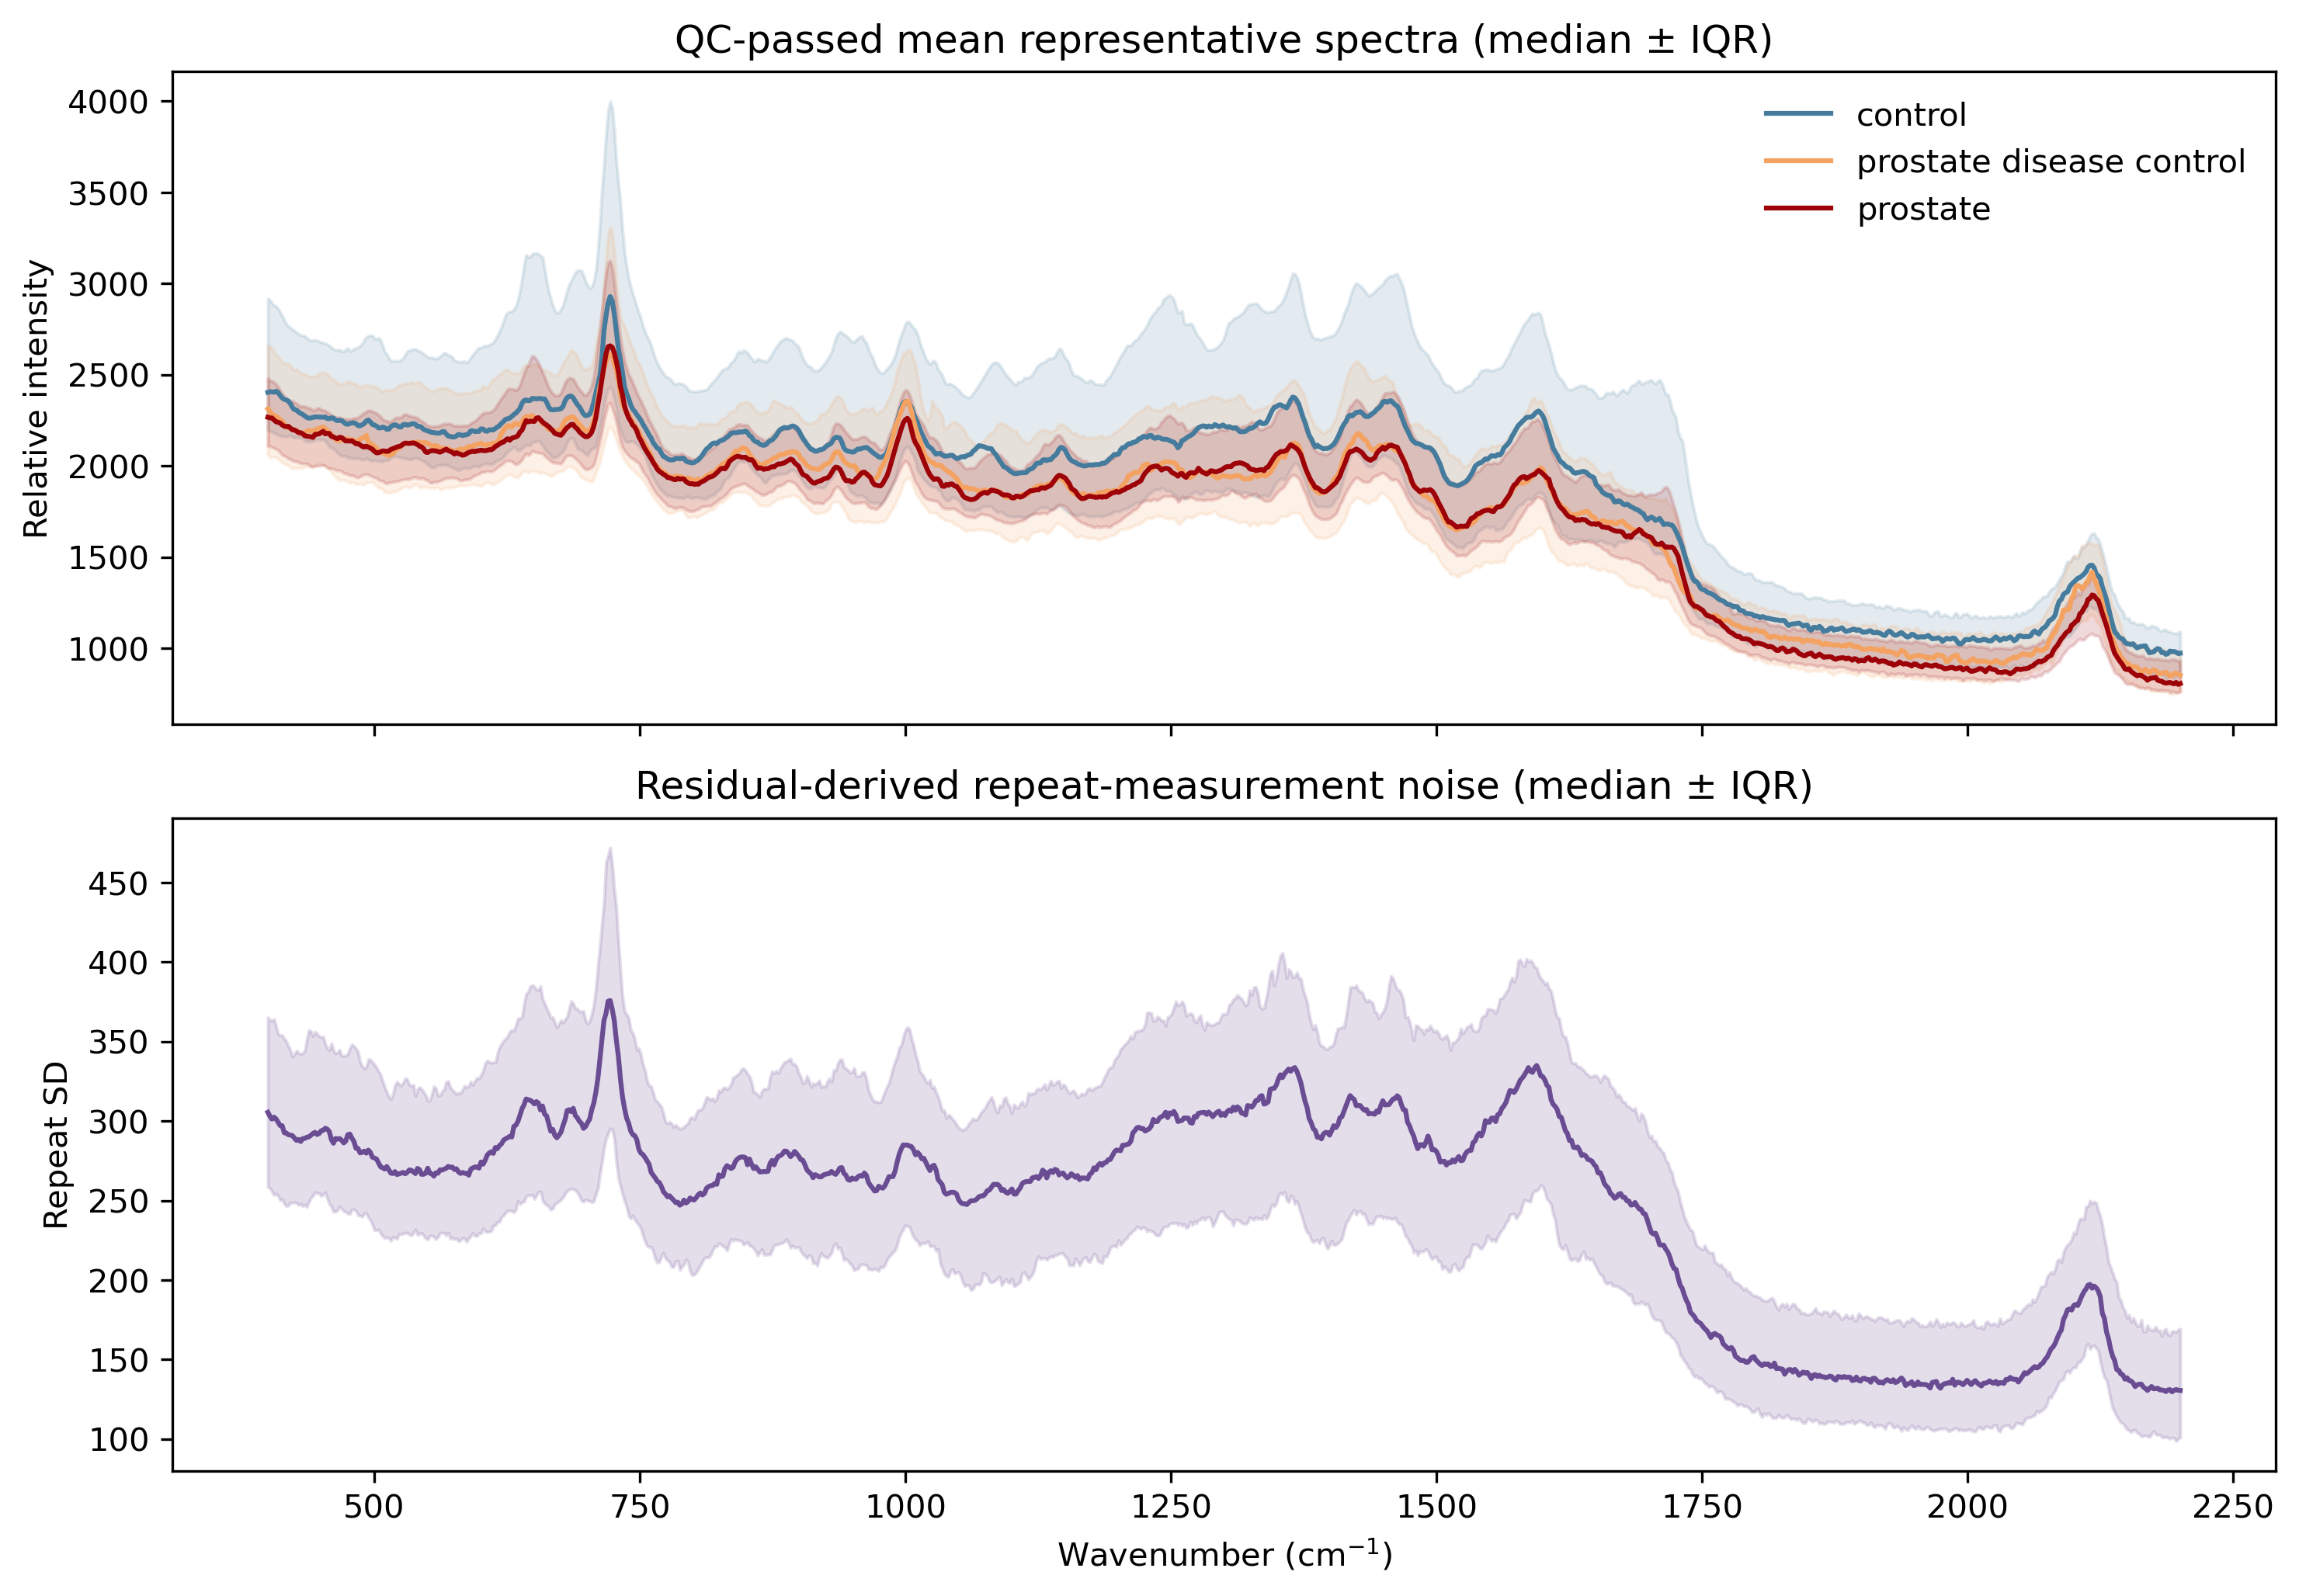

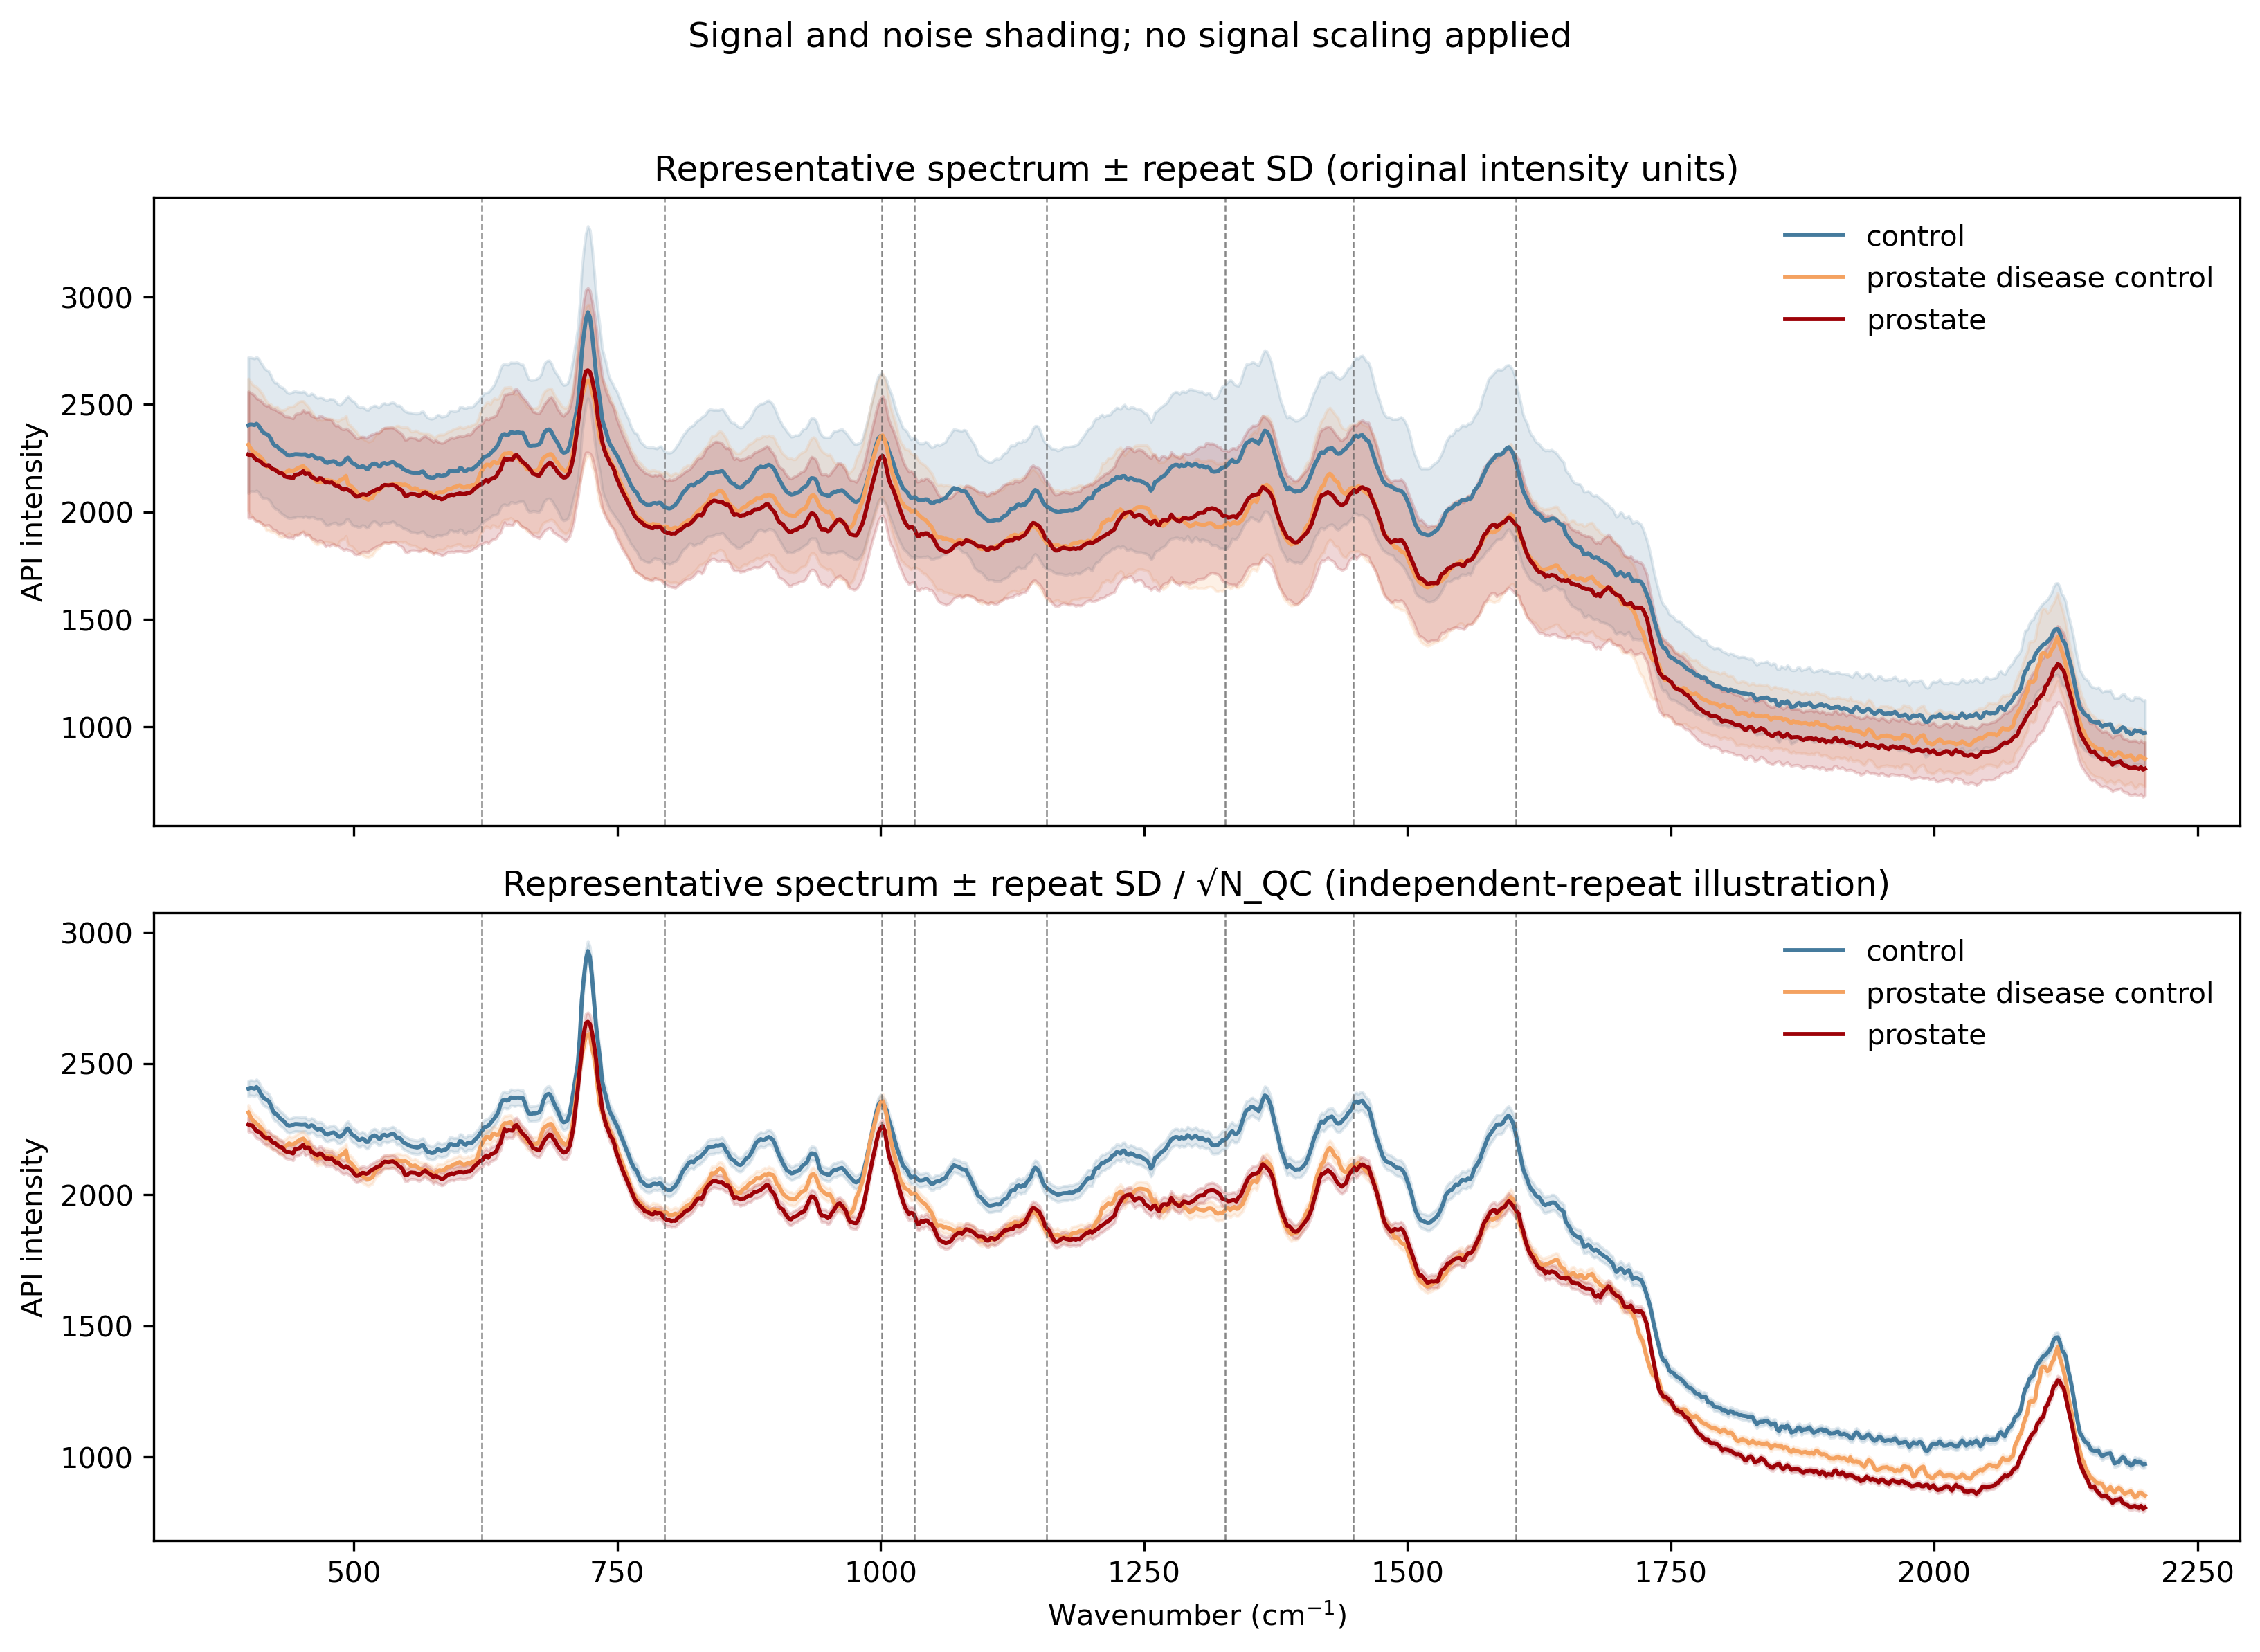

In [4]:
qc_summary = pd.read_csv(OUTPUT_DIR / "qc_summary.csv")
subject_qc = pd.read_csv(OUTPUT_DIR / "subject_qc_noise_summary.csv")
print(qc_summary.to_dict(orient="records")[0])
display(
    subject_qc.groupby("label", as_index=False)
    .agg(
        subjects=("subject_index_internal", "size"),
        repeats_total=("repeats_total", "sum"),
        repeats_passed=("repeats_passed", "sum"),
        repeats_excluded=("repeats_excluded", "sum"),
        qc_pass_rate=("qc_pass_rate", "mean"),
        noise_sigma_median=("noise_floor_global_median", "median"),
    )
)
display(Image(filename=str(FIGURE_DIR / "representative_spectrum_and_noise.png")))
display(Image(filename=str(FIGURE_DIR / "spectrum_noise_shading.png")))

### 4. SNR and resolution-aware peak registry

{'snr_candidates': 29, 'resolution_registry_rows': 9, 'common_candidates': 7, 'max_repeat_level_snr': 2.2223774084861936, 'max_independent_mean_snr': 23.86792218792258}


,label,rank_by_prominence,peak_wavenumber_cm1,is_reference_peak,peak_intensity_raw,peak_prominence_local_contrast,noise_sigma_at_peak,noise_floor_global_median,median_qc_repeats,snr_raw_over_local_noise,snr_raw_over_noise_floor,snr_contrast_over_local_noise,snr_contrast_over_noise_floor,snr_contrast_over_mean_noise_independent
10,prostate,2,2117.041801,False,1292.453096,392.929464,177.308264,263.174732,116.0,7.289300,4.911008,2.216081,1.493036,23.867922
18,prostate disease control,1,2117.041801,False,1417.902538,456.754319,205.525091,266.495466,115.0,6.898927,5.320550,2.222377,1.713929,23.832343
1,control,2,2117.041801,False,1455.923574,388.081469,213.240443,281.768972,114.0,6.827615,5.167083,1.819924,1.377304,19.431474
0,control,1,722.186495,False,2928.939699,653.165964,400.823506,281.768972,114.0,7.307305,10.394827,1.629560,2.318090,17.398940
19,prostate disease control,2,1001.929260,True,2356.336407,444.065024,286.441539,266.495466,115.0,8.226238,8.841938,1.550282,1.666314,16.624917
11,prostate,3,1001.929260,True,2261.398026,370.509155,277.568656,263.174732,116.0,8.147166,8.592763,1.334838,1.407845,14.376644
9,prostate,1,722.186495,False,2658.953027,498.788965,382.474506,263.174732,116.0,6.951975,10.103375,1.304110,1.895277,14.045698
20,prostate disease control,3,724.115756,False,2612.964162,422.510138,350.687352,266.495466,115.0,7.450979,9.804910,1.204806,1.585431,12.920102
2,control,3,1000.000000,True,2353.704168,307.125960,289.565049,281.768972,114.0,8.128413,8.353312,1.060646,1.089992,11.324598
21,prostate disease control,4,1426.366559,False,2177.941754,315.582325,306.914280,266.495466,115.0,7.096254,8.172528,1.028243,1.184194,11.026673


,peak_id,representative_wavenumber_cm1,label_count,labels_present,common_candidate,max_prominence_local_contrast,max_snr_contrast_mean_independent,min_snr_contrast_mean_independent,match_tolerance_cm1,candidate_centers_by_label,candidate_mean_snr_by_label
0,common_peak_01,722.186495,3,control|prostate|prostate disease control,True,616.903108,16.432975,12.165498,2.0,"{""control"": 722.1864951768489, ""prostate"": 722...","{""control"": 16.432975236565042, ""prostate"": 13..."
1,common_peak_02,1001.929260,3,control|prostate|prostate disease control,True,353.935489,13.250645,9.873549,2.0,"{""control"": 1000.0, ""prostate"": 1001.929260450...","{""control"": 9.873548571130385, ""prostate"": 12...."
2,common_peak_03,1144.694534,3,control|prostate|prostate disease control,True,96.650803,3.884077,3.150606,2.0,"{""control"": 1146.6237942122186, ""prostate"": 11...","{""control"": 3.1506063714592076, ""prostate"": 3...."
3,common_peak_04,1364.630225,2,control|prostate,True,155.726403,4.439067,3.880795,2.0,"{""control"": 1364.630225080386, ""prostate"": 136...","{""control"": 4.439067219513936, ""prostate"": 3.8..."
4,common_peak_05,1366.559486,1,prostate disease control,False,178.003982,5.926299,5.926299,2.0,"{""prostate disease control"": 1366.5594855305467}","{""prostate disease control"": 5.926298949366527}"
5,common_peak_06,1434.083601,1,prostate disease control,False,125.051134,4.469562,4.469562,2.0,"{""prostate disease control"": 1434.0836012861737}","{""prostate disease control"": 4.46956245719771}"
6,common_peak_07,1457.234727,2,control|prostate,True,142.230706,4.109642,3.910237,2.0,"{""control"": 1457.234726688103, ""prostate"": 145...","{""control"": 4.109642054897216, ""prostate"": 3.9..."
7,common_peak_08,1596.141479,3,control|prostate|prostate disease control,True,245.148236,6.917113,6.588258,2.0,"{""control"": 1596.1414790996785, ""prostate"": 15...","{""control"": 6.861850589642534, ""prostate"": 6.5..."
8,common_peak_09,2117.041801,3,control|prostate|prostate disease control,True,365.844260,19.408472,15.286318,2.0,"{""control"": 2117.041800643087, ""prostate"": 211...","{""control"": 15.286317624584298, ""prostate"": 19..."


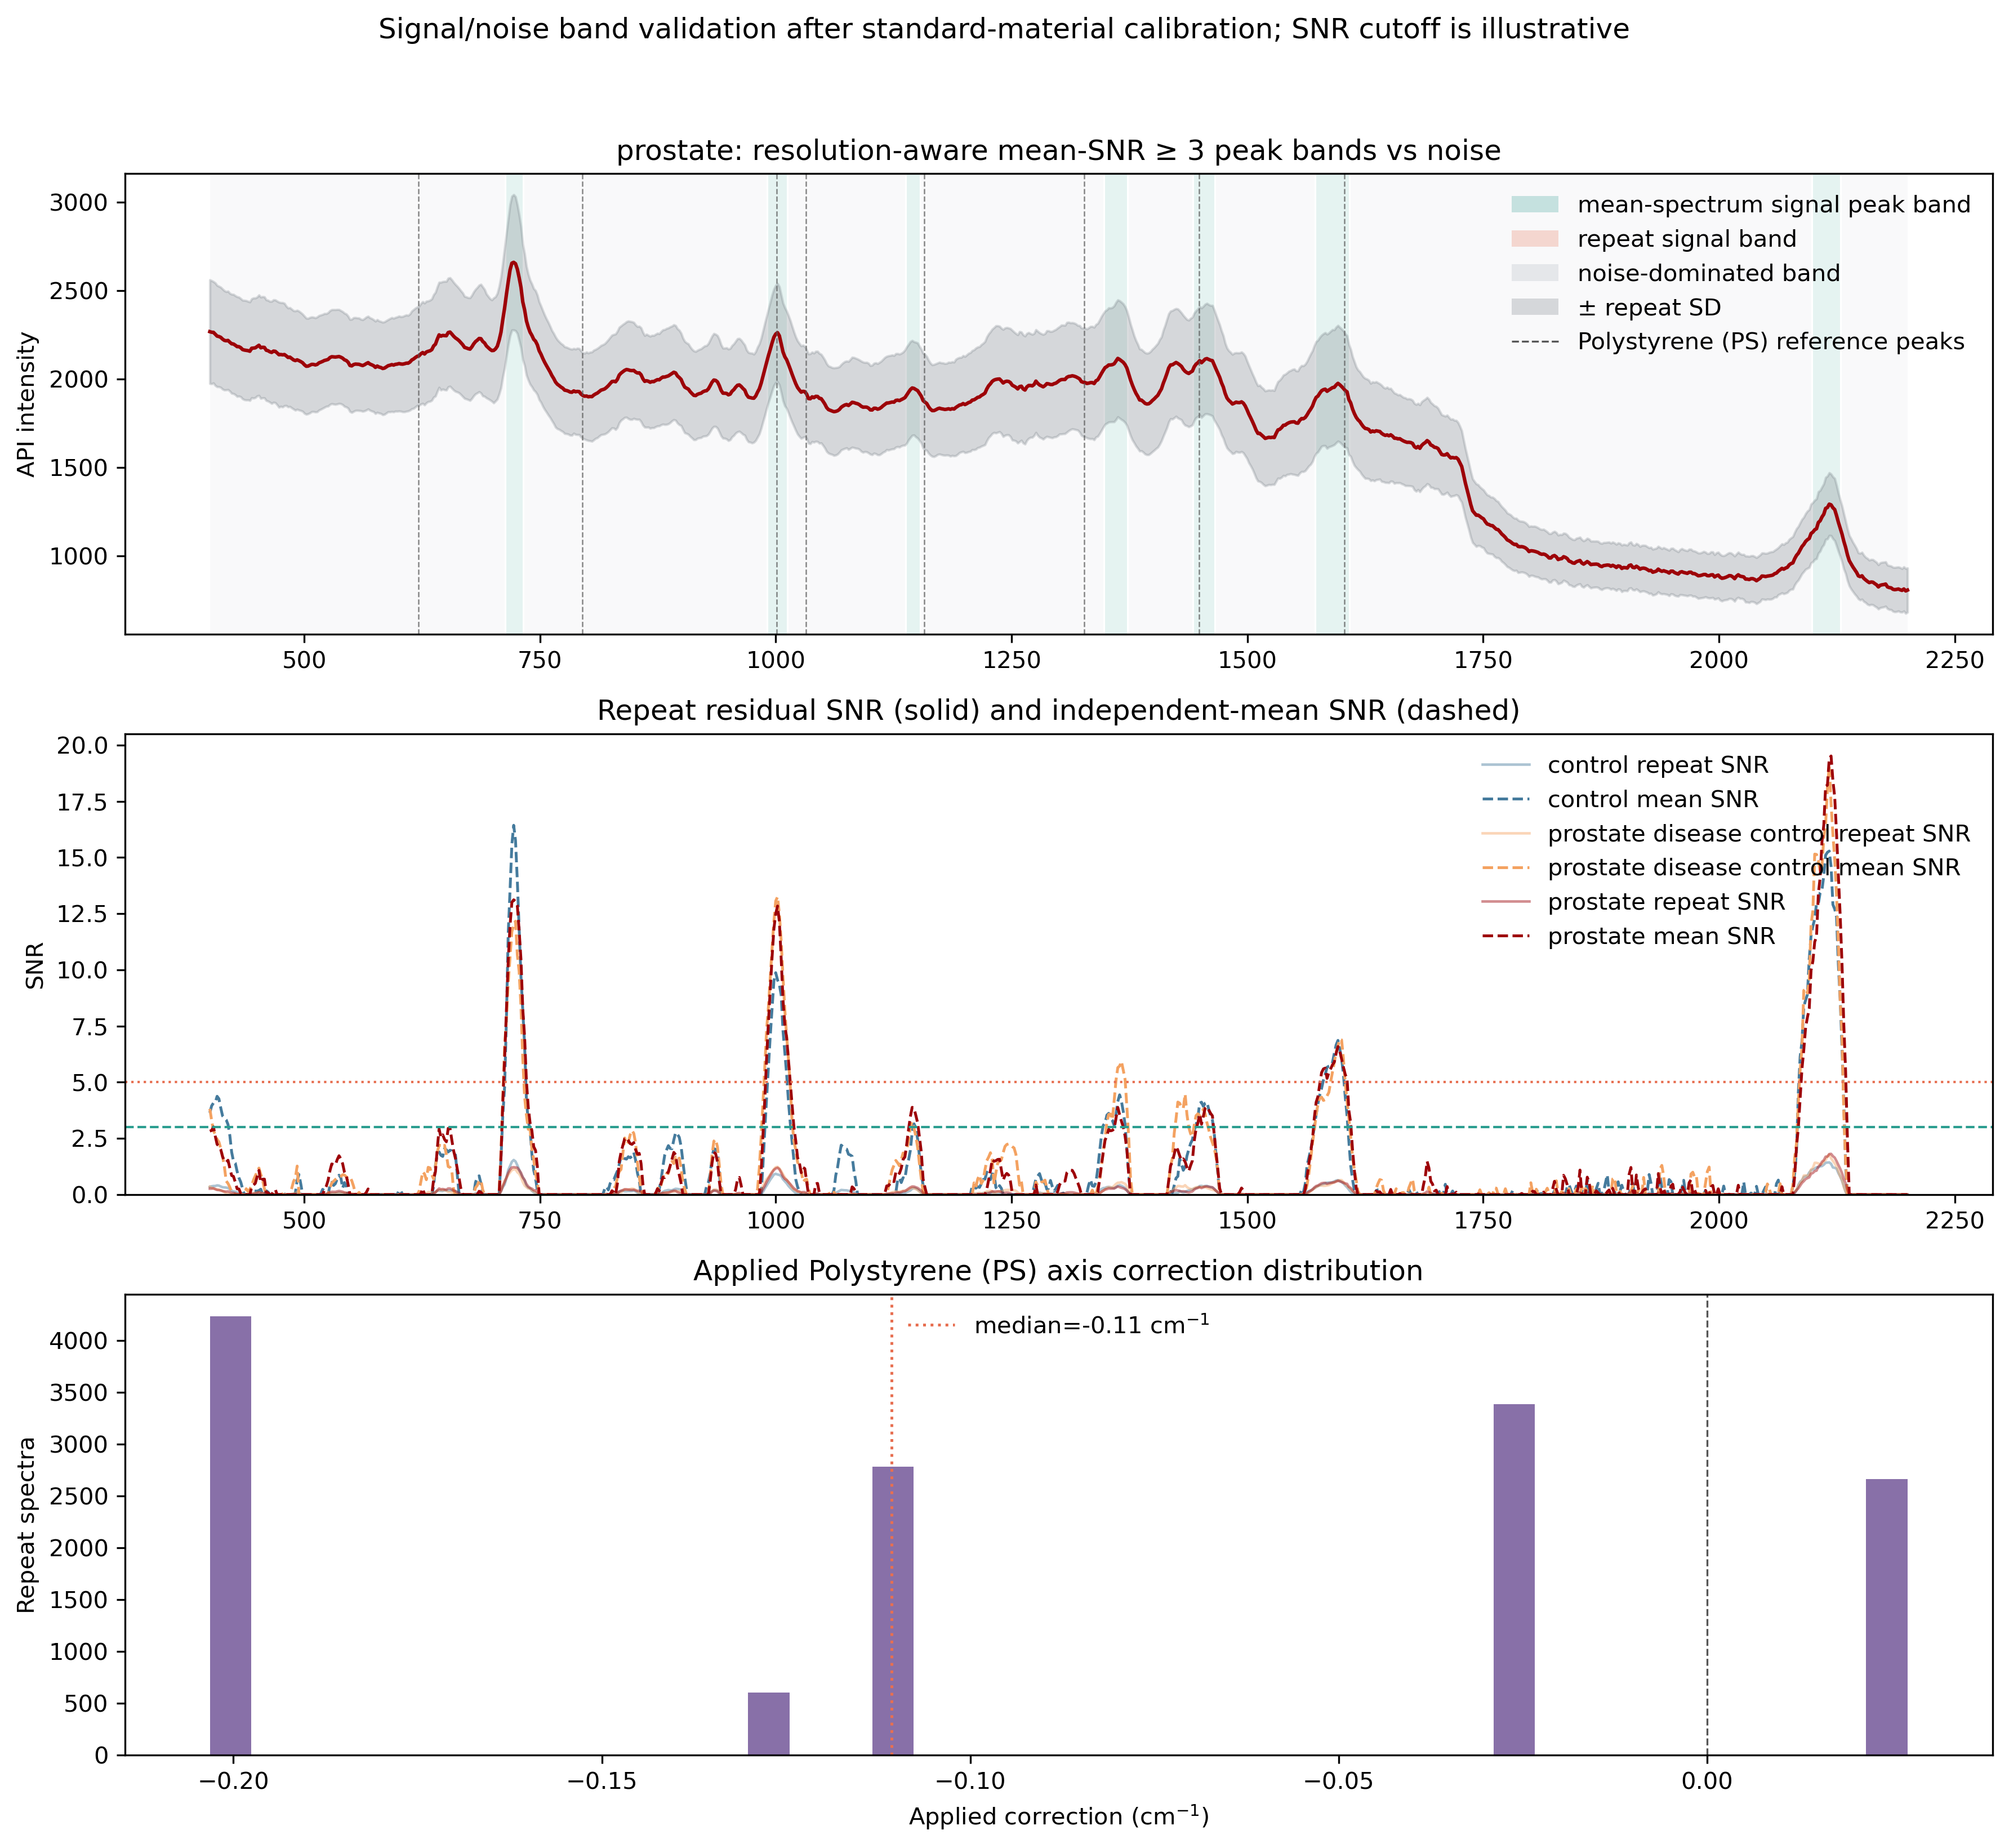

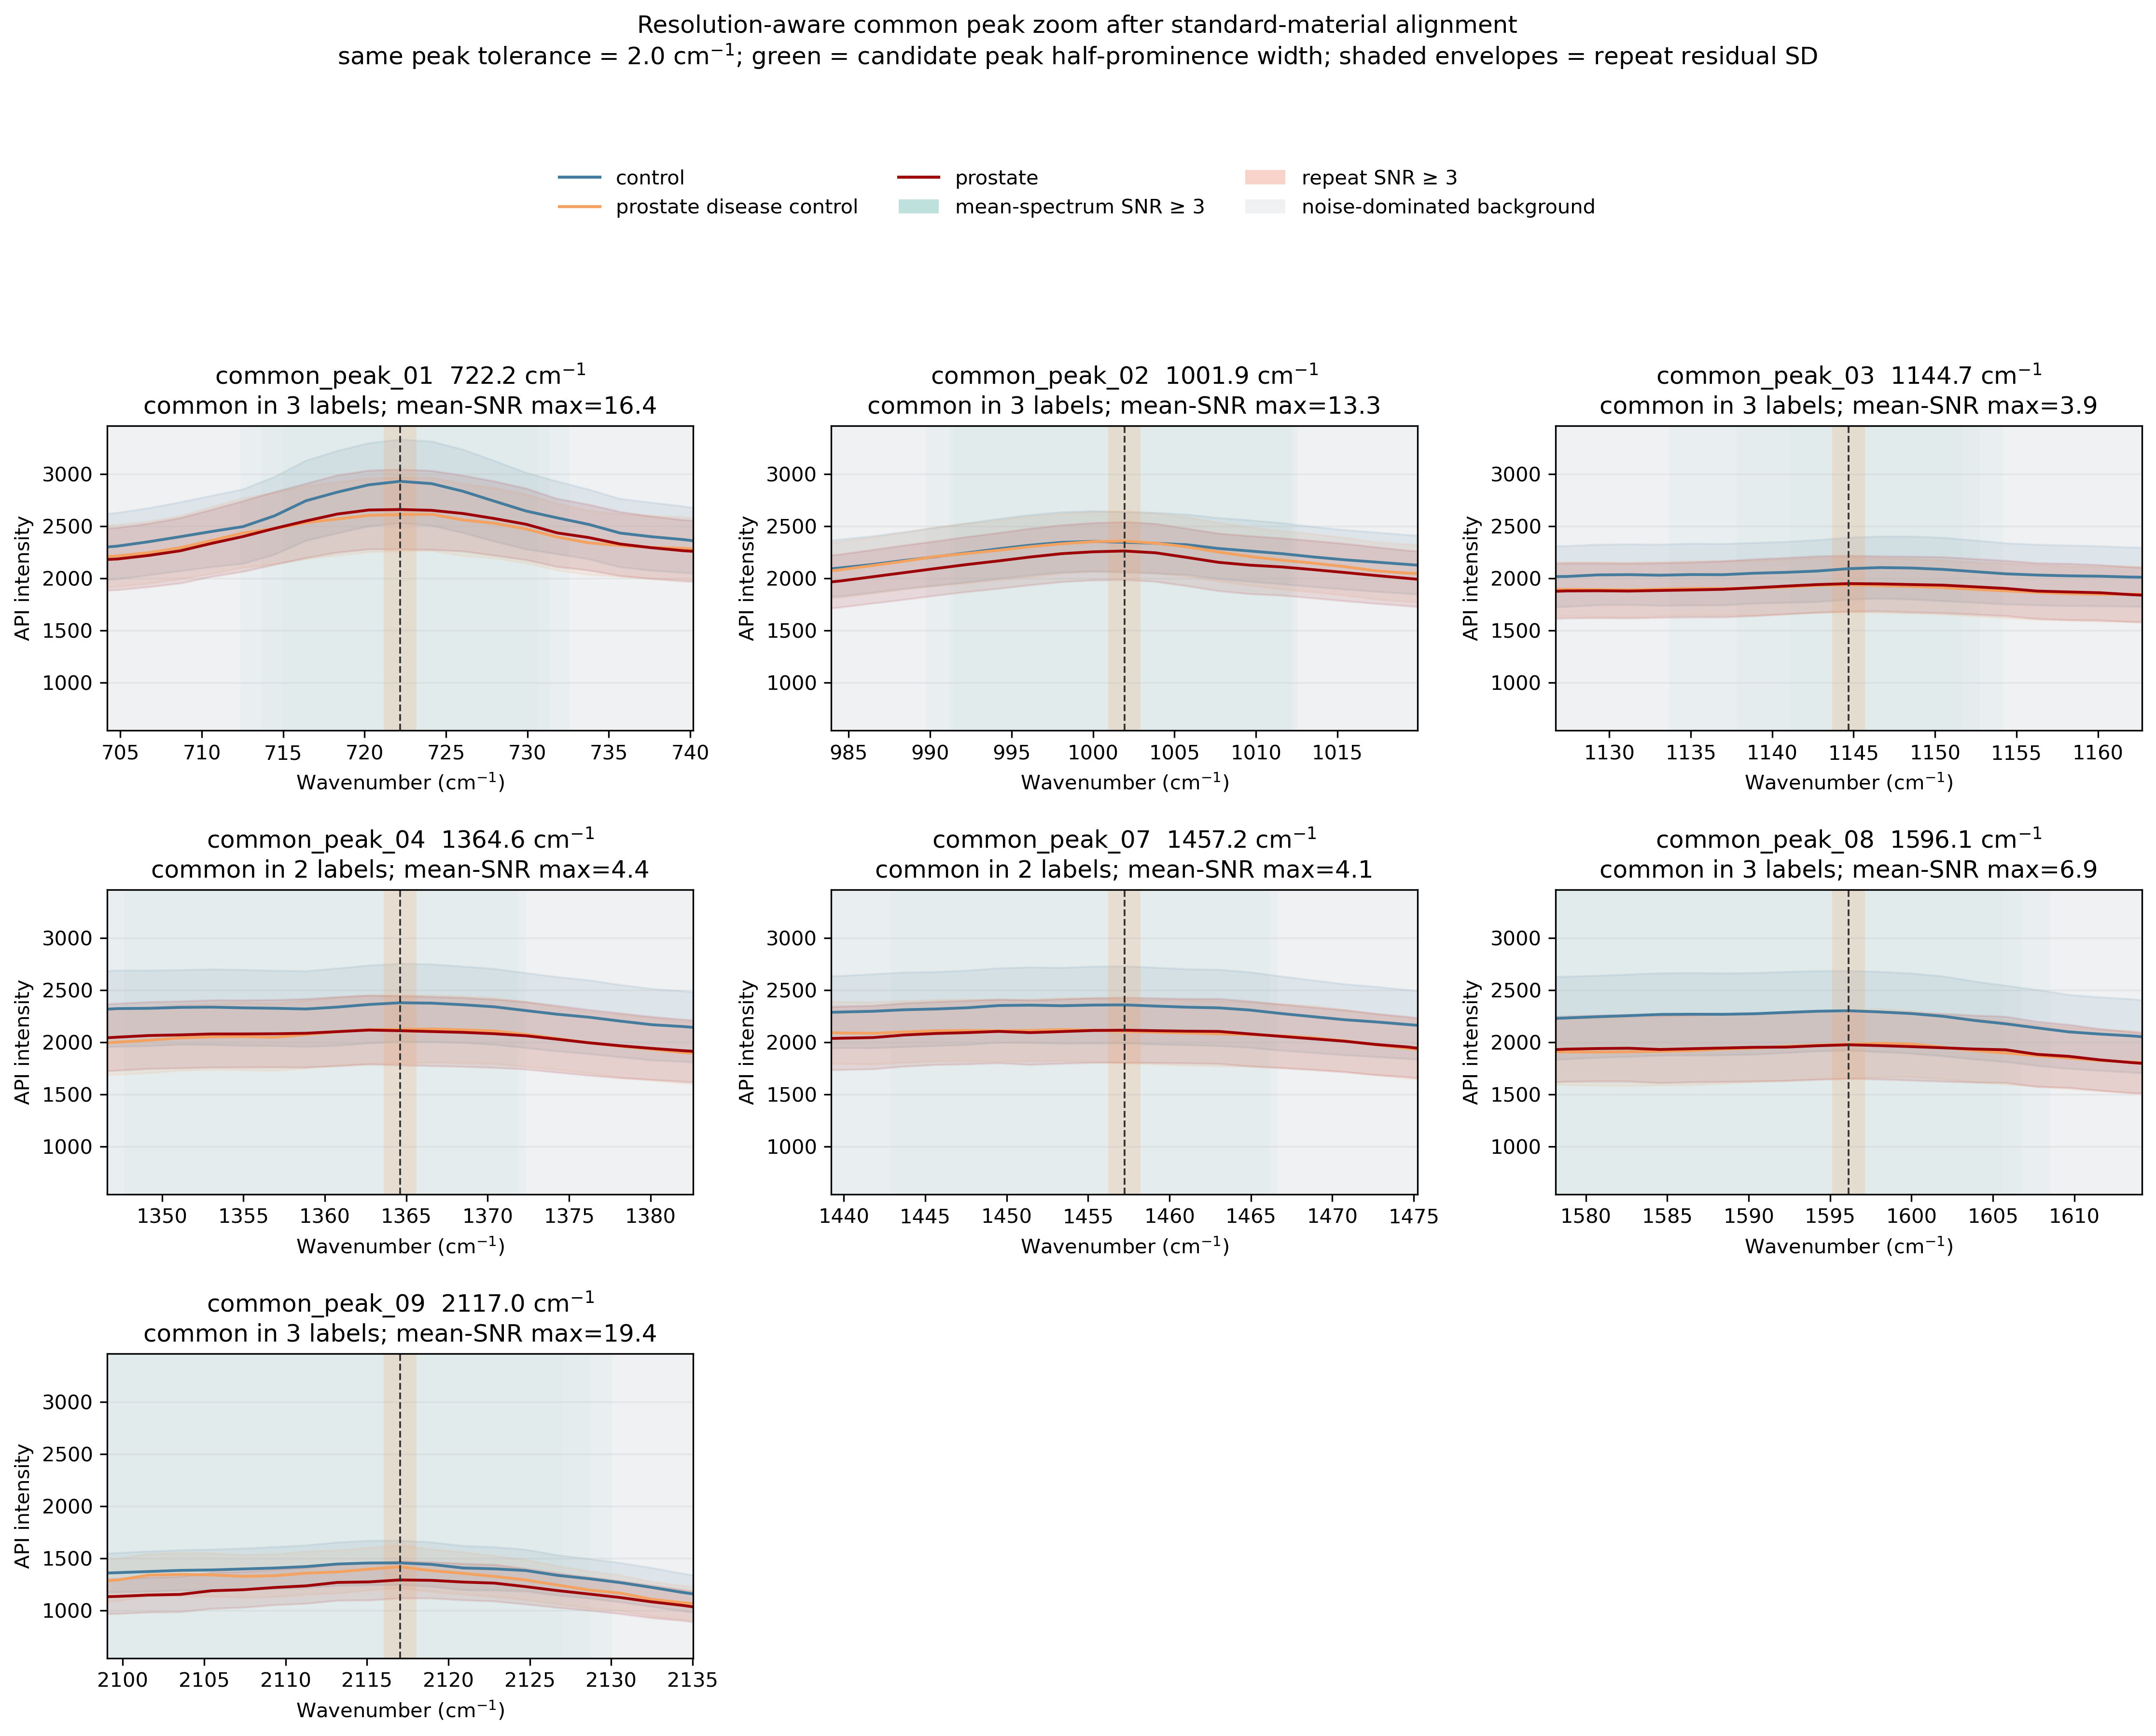

In [5]:
snr_summary = pd.read_csv(OUTPUT_DIR / "snr_peak_summary.csv")
peak_registry = pd.read_csv(OUTPUT_DIR / "resolution_aware_peak_registry.csv")
print({
    "snr_candidates": len(snr_summary),
    "resolution_registry_rows": len(peak_registry),
    "common_candidates": int(peak_registry["common_candidate"].sum()),
    "max_repeat_level_snr": float(snr_summary["snr_contrast_over_local_noise"].max()),
    "max_independent_mean_snr": float(snr_summary["snr_contrast_over_mean_noise_independent"].max()),
})
display(
    snr_summary.sort_values(
        ["snr_contrast_over_mean_noise_independent", "label"],
        ascending=[False, True],
    ).head(30)
)
display(peak_registry)
display(Image(filename=str(FIGURE_DIR / "signal_noise_band_validation.png")))
display(Image(filename=str(FIGURE_DIR / "resolution_aware_peak_zoom.png")))

### 5. Direct raw mean-spectrum clinical performance and threshold policy

{'name': 'direct raw mean-spectrum stacking', 'base_models': ['StandardScaler + LogisticRegression(C=1.0)', 'XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05)', 'RandomForestClassifier(n_estimators=400)', 'StandardScaler + LogisticRegression(C=0.1)'], 'meta_model': 'elastic-net LogisticRegression', 'evaluation': 'subject-level nested GroupKFold(outer=5, inner=5)', 'decision_threshold': 0.4544682703066162, 'decision_threshold_policy': 'outer-train inner-meta OOF balanced-accuracy optimum', 'fixed_comparison_threshold': 0.4, 'random_state': 20260825}


,fold,n_train_subjects,n_test_subjects,test_positive_subjects,test_negative_subjects,auc,balanced_accuracy,threshold,threshold_selection_balanced_accuracy
0,1,90,23,9,14,0.904762,0.730159,0.354056,0.652836
1,2,90,23,9,14,0.793651,0.710317,0.375962,0.621324
2,3,90,23,9,14,0.682540,0.595238,0.454468,0.625525
3,4,91,22,8,14,0.473214,0.580357,0.464083,0.728571
4,5,91,22,8,14,0.580357,0.464286,0.512054,0.717857


,method,threshold,threshold_policy,threshold_mean,threshold_median,threshold_min,threshold_max,threshold_std,fixed_comparison_threshold,fixed_comparison_balanced_accuracy,...,fold_balanced_accuracy_mean,fold_balanced_accuracy_std,true_negative,false_positive,false_negative,true_positive,fixed_comparison_true_negative,fixed_comparison_false_positive,fixed_comparison_false_negative,fixed_comparison_true_positive
0,direct_qc_passed_mean_spectrum_stacking,0.454468,outer-train inner-meta OOF balanced-accuracy o...,0.432125,0.454468,0.354056,0.512054,0.05858,0.4,0.630897,...,0.616071,0.107989,53,17,22,21,46,24,17,26


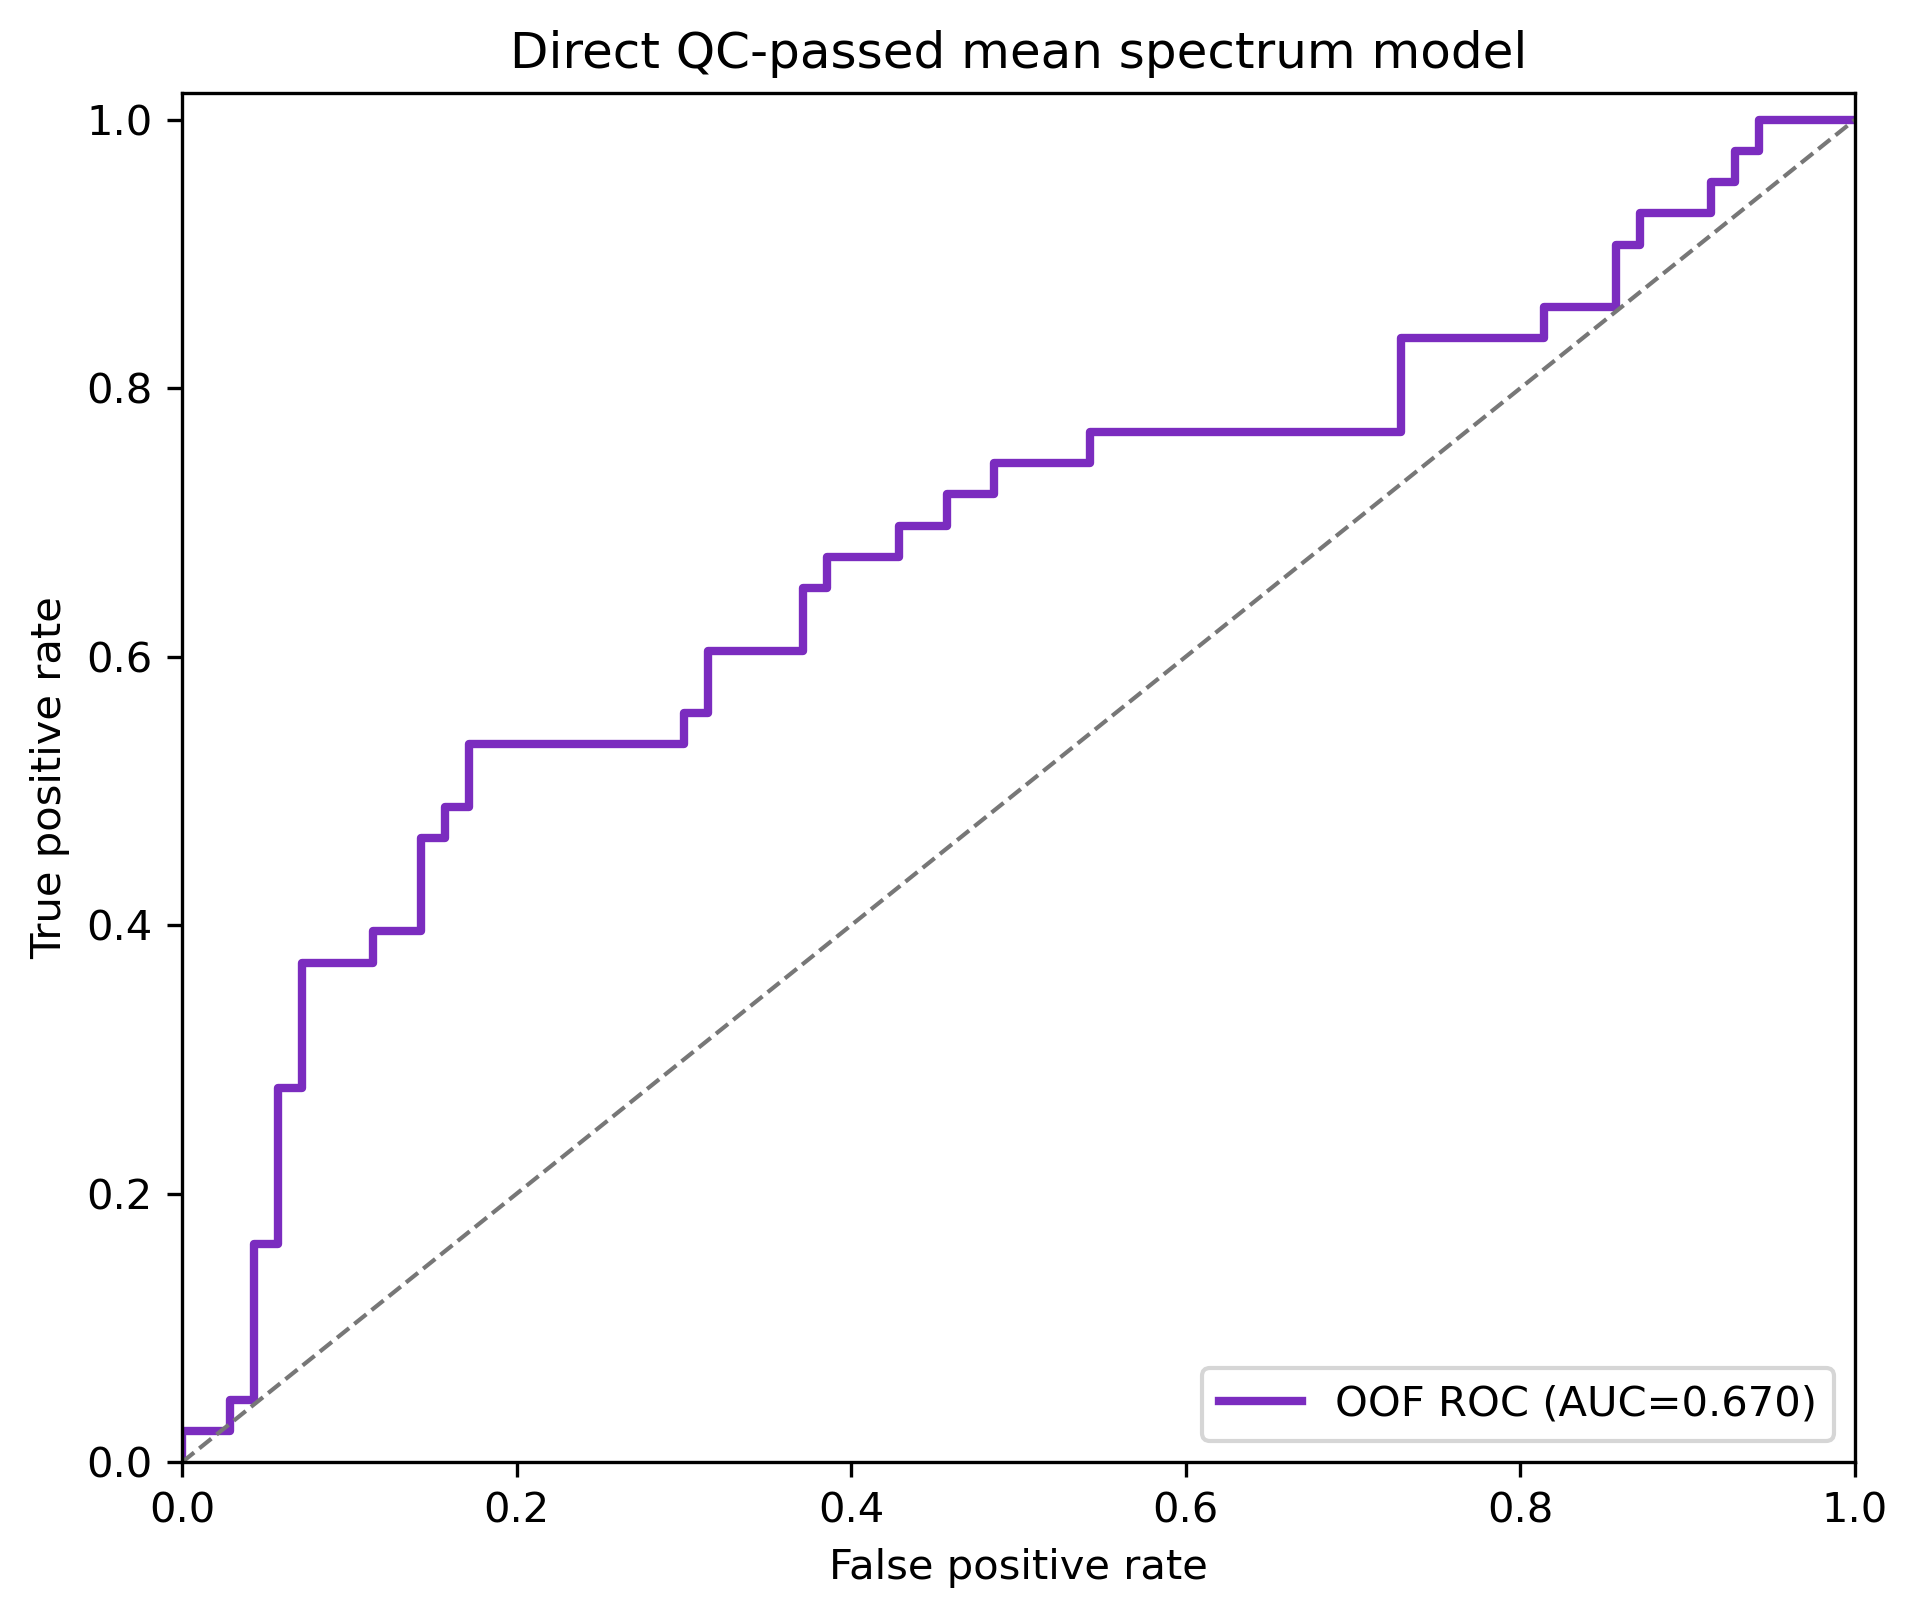

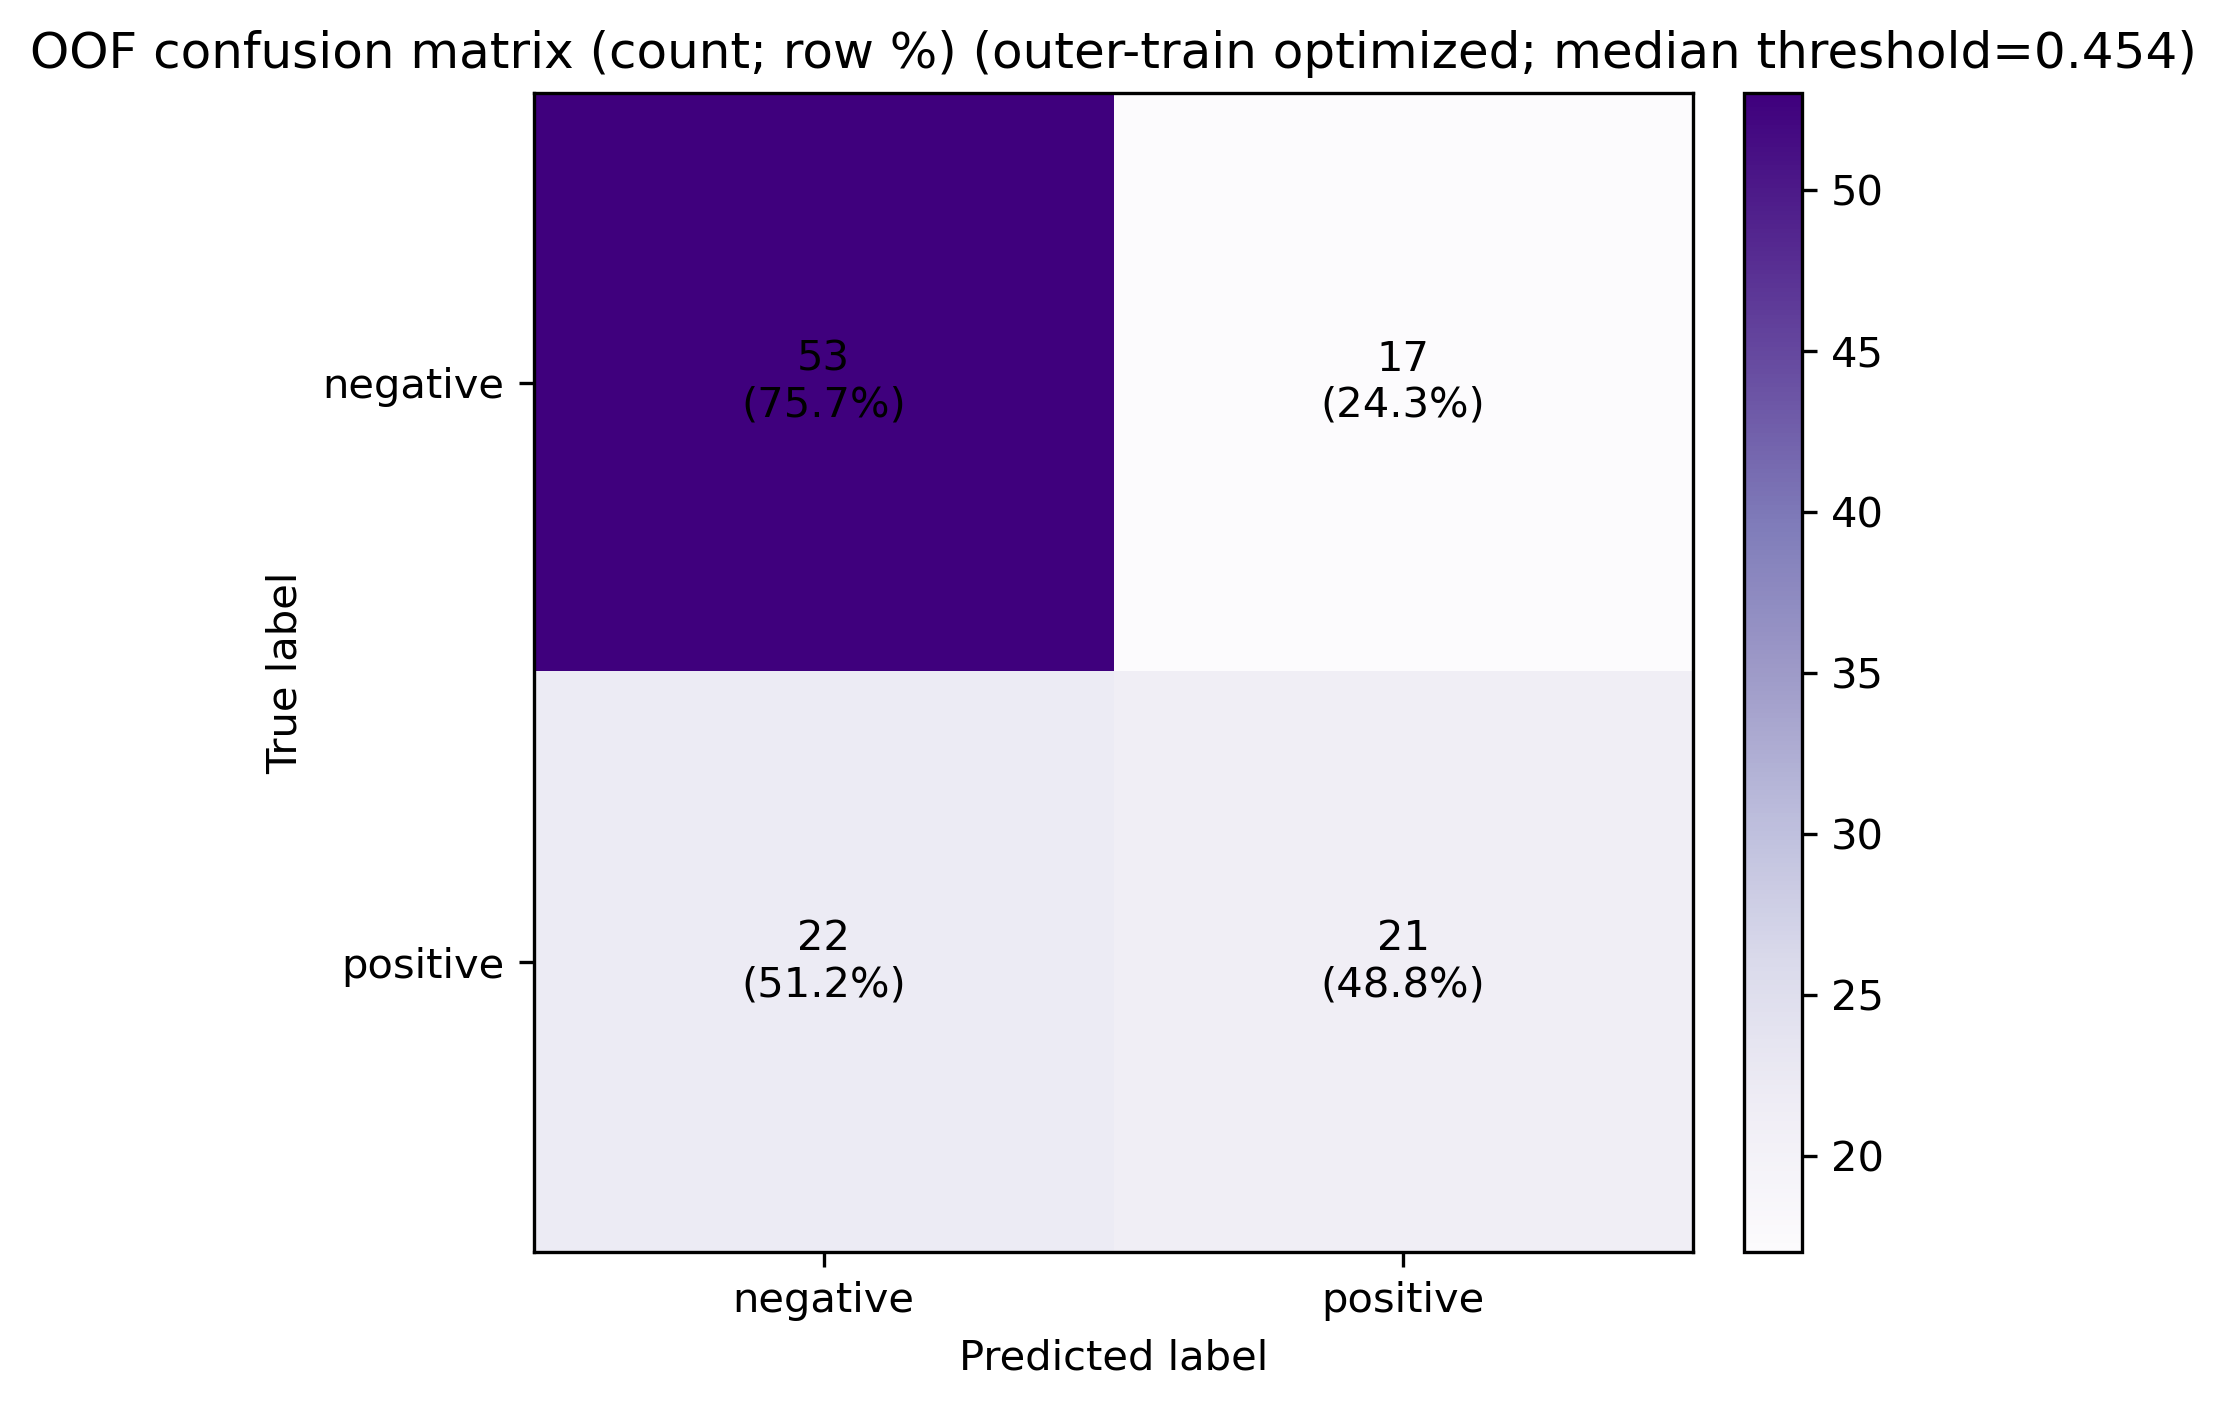

In [6]:
performance = pd.read_csv(OUTPUT_DIR / "clinical_performance_summary.csv", encoding="utf-8-sig")
fold_metrics = pd.read_csv(OUTPUT_DIR / "clinical_fold_metrics.csv", encoding="utf-8-sig")
print(metadata["model"])
display(fold_metrics)
display(performance)
display(Image(filename=str(FIGURE_DIR / "clinical_roc.png")))
display(Image(filename=str(FIGURE_DIR / "confusion_matrix.png")))

### 6. STK-V2 canonical comparison

In [7]:
import shutil
import sys

import numpy as np

import matplotlib.pyplot as plt
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

LEGACY_ANALYSIS_DIR = REPO_ROOT / "notebooks"
if str(LEGACY_ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(LEGACY_ANALYSIS_DIR))

from build_stkv2_dataset import extract_peak_features
from stk_v2_preprocess import STK_TARGET_GRID, stk_v2_channels
from train_stkv2_stacking import build_views, run_nested_cv

mean_spectrum_frame = pd.read_csv(
    OUTPUT_DIR / "mean_representative_spectra.csv",
    encoding="utf-8-sig",
)
mean_columns = [
    column
    for column in mean_spectrum_frame.columns
    if column.startswith("wn_")
]
stk_source_grid = np.asarray([
    float(column.removeprefix("wn_"))
    for column in mean_columns
])
stk_raw_means = mean_spectrum_frame[mean_columns].to_numpy(dtype=np.float64)
stk_labels = mean_spectrum_frame["label"].astype(str).to_numpy()
stk_y = (stk_labels == "prostate").astype(int)
stk_groups = np.arange(len(stk_y), dtype=int)

stk_channels = np.stack([
    stk_v2_channels(stk_source_grid, row)
    for row in stk_raw_means
])
stk_peak_features = np.vstack([
    extract_peak_features(STK_TARGET_GRID, row)
    for row in stk_channels[:, 0, :]
])
stk_views = build_views({
    "raw": stk_channels[:, 0, :],
    "d1": stk_channels[:, 1, :],
    "d2": stk_channels[:, 2, :],
    "peak": stk_peak_features,
})
stk_views_summary = pd.DataFrame([
    {
        "view": name,
        "subjects": matrix.shape[0],
        "features": matrix.shape[1],
    }
    for name, matrix in stk_views.items()
])
print({
    "subjects": len(stk_y),
    "positive_subjects": int(stk_y.sum()),
    "negative_subjects": int((stk_y == 0).sum()),
    "source_points": len(stk_source_grid),
    "stk_target_points": len(STK_TARGET_GRID),
    "peak_features": stk_peak_features.shape[1],
})
display(stk_views_summary)

{'subjects': 113, 'positive_subjects': 43, 'negative_subjects': 70, 'source_points': 934, 'stk_target_points': 935, 'peak_features': 75}


,view,subjects,features
0,raw,113,935
1,d1,113,935
2,d2,113,935
3,concat,113,2805
4,peak,113,75


In [8]:
stk_details = run_nested_cv(
    views=stk_views,
    y=stk_y,
    groups=stk_groups,
    n_outer=5,
    n_inner=5,
    seed=analysis.RANDOM_STATE,
    tune_threshold=True,
    return_details=True,
)
stk_oof_probability = np.asarray(stk_details["oof_probability"], dtype=np.float64)
stk_oof_prediction = np.asarray(stk_details["oof_prediction"], dtype=int)
stk_threshold_used = np.asarray(stk_details["oof_threshold"], dtype=np.float64)
stk_fold_metrics = pd.DataFrame(stk_details["fold_metrics"])

def summarize_predictions(
    model_name,
    policy,
    threshold,
    y_true,
    probability,
    prediction,
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1],
    ).ravel()
    return {
        "model": model_name,
        "policy": policy,
        "threshold": float(threshold),
        "overall_oof_auc": float(roc_auc_score(y_true, probability)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, prediction)
        ),
        "f1": float(f1_score(y_true, prediction, zero_division=0)),
        "precision": float(
            precision_score(y_true, prediction, zero_division=0)
        ),
        "recall": float(recall_score(y_true, prediction, zero_division=0)),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }

stk_threshold_median = float(stk_fold_metrics["threshold"].median())
stk_performance = pd.DataFrame([
    summarize_predictions(
        "STK-V2",
        "outer-train inner-meta OOF balanced-accuracy optimum",
        stk_threshold_median,
        stk_y,
        stk_oof_probability,
        stk_oof_prediction,
    )
])
stk_fixed_prediction = (stk_oof_probability >= 0.4).astype(int)
stk_fixed_performance = pd.DataFrame([
    summarize_predictions(
        "STK-V2",
        "fixed threshold 0.4",
        0.4,
        stk_y,
        stk_oof_probability,
        stk_fixed_prediction,
    )
])
stk_performance.insert(2, "threshold_mean", float(stk_fold_metrics["threshold"].mean()))
stk_performance.insert(3, "threshold_min", float(stk_fold_metrics["threshold"].min()))
stk_performance.insert(4, "threshold_max", float(stk_fold_metrics["threshold"].max()))
stk_performance.insert(5, "threshold_std", float(stk_fold_metrics["threshold"].std(ddof=0)))
stk_fixed_performance["threshold_mean"] = np.nan
stk_fixed_performance["threshold_min"] = np.nan
stk_fixed_performance["threshold_max"] = np.nan
stk_fixed_performance["threshold_std"] = np.nan

stk_oof_frame = pd.DataFrame({
    "subject_index_internal": np.arange(len(stk_y)),
    "label": stk_labels,
    "y_true": stk_y,
    "oof_probability": stk_oof_probability,
    "prediction": stk_oof_prediction,
    "threshold_used": stk_threshold_used,
    "prediction_fixed_0_4": stk_fixed_prediction,
})
stk_fold_metrics.to_csv(
    OUTPUT_DIR / "stk_v2_canonical_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
stk_performance.to_csv(
    OUTPUT_DIR / "stk_v2_canonical_performance_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
stk_oof_frame.to_csv(
    OUTPUT_DIR / "stk_v2_canonical_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)
stk_views_summary.to_csv(
    OUTPUT_DIR / "stk_v2_canonical_views_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
print("STK-V2 tuned performance")
display(stk_fold_metrics)
display(stk_performance)
display(stk_fixed_performance)

  [outer 1] AUC=0.8968  balanced_acc=0.6310


  [outer 2] AUC=0.6508  balanced_acc=0.5278


  [outer 3] AUC=0.6825  balanced_acc=0.5635


  [outer 4] AUC=0.7857  balanced_acc=0.5893


  [outer 5] AUC=0.6964  balanced_acc=0.6339
STK-V2 tuned performance


,fold,auc,balanced_accuracy,threshold,threshold_selection_balanced_accuracy
0,1,0.896825,0.630952,0.531668,0.655462
1,2,0.650794,0.527778,0.351486,0.733718
2,3,0.682540,0.563492,0.364572,0.787290
3,4,0.785714,0.589286,0.294341,0.716071
4,5,0.696429,0.633929,0.263554,0.732143


,model,policy,threshold_mean,threshold_min,threshold_max,threshold_std,threshold,overall_oof_auc,balanced_accuracy,f1,precision,recall,true_negative,false_positive,false_negative,true_positive
0,STK-V2,outer-train inner-meta OOF balanced-accuracy o...,0.361124,0.263554,0.531668,0.092919,0.351486,0.731561,0.586213,0.510638,0.470588,0.55814,43,27,19,24


,model,policy,threshold,overall_oof_auc,balanced_accuracy,f1,precision,recall,true_negative,false_positive,false_negative,true_positive,threshold_mean,threshold_min,threshold_max,threshold_std
0,STK-V2,fixed threshold 0.4,0.4,0.731561,0.672924,0.610526,0.557692,0.674419,47,23,14,29,NaN,NaN,NaN,NaN


In [9]:
def threshold_sweep(model_name, y_true, probability):
    candidates = np.linspace(0.05, 0.95, 181)
    return pd.DataFrame([
        {
            "model": model_name,
            "threshold": float(threshold),
            "balanced_accuracy": float(
                balanced_accuracy_score(
                    y_true,
                    probability >= threshold,
                )
            ),
        }
        for threshold in candidates
    ])

direct_oof = pd.read_csv(
    OUTPUT_DIR / "oof_predictions.csv",
    encoding="utf-8-sig",
)
direct_y = direct_oof["y_true"].to_numpy(dtype=int)
direct_probability = direct_oof["oof_probability"].to_numpy(dtype=float)
direct_tuned_threshold = float(performance["threshold_median"].iloc[0])
direct_tuned_prediction = direct_oof["prediction"].to_numpy(dtype=int)
direct_fixed_prediction = direct_oof["prediction_fixed_0_4"].to_numpy(dtype=int)

direct_tuned_row = summarize_predictions(
    "Direct raw mean-spectrum",
    str(performance["threshold_policy"].iloc[0]),
    direct_tuned_threshold,
    direct_y,
    direct_probability,
    direct_tuned_prediction,
)
direct_fixed_row = summarize_predictions(
    "Direct raw mean-spectrum",
    "fixed threshold 0.4",
    0.4,
    direct_y,
    direct_probability,
    direct_fixed_prediction,
)

direct_sweep = threshold_sweep(
    "Direct raw mean-spectrum",
    direct_y,
    direct_probability,
)
stk_sweep = threshold_sweep("STK-V2", stk_y, stk_oof_probability)
threshold_sweep_frame = pd.concat(
    [direct_sweep, stk_sweep],
    ignore_index=True,
)
threshold_sweep_frame.to_csv(
    OUTPUT_DIR / "threshold_sweep_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

descriptive_rows = []
for model_name, sweep, y_true, probability in [
    ("Direct raw mean-spectrum", direct_sweep, direct_y, direct_probability),
    ("STK-V2", stk_sweep, stk_y, stk_oof_probability),
]:
    best_row = sweep.loc[sweep["balanced_accuracy"].idxmax()]
    descriptive_rows.append(
        summarize_predictions(
            model_name,
            "full-OOF sweep (descriptive; optimistic)",
            float(best_row["threshold"]),
            y_true,
            probability,
            probability >= float(best_row["threshold"]),
        )
    )

comparison = pd.DataFrame([
    direct_tuned_row,
    direct_fixed_row,
    *descriptive_rows,
    *stk_performance.to_dict(orient="records"),
    *stk_fixed_performance.to_dict(orient="records"),
])
comparison.to_csv(
    OUTPUT_DIR / "model_comparison_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Primary comparison: outer-train threshold policy")
display(comparison)

Primary comparison: outer-train threshold policy


,model,policy,threshold,overall_oof_auc,balanced_accuracy,f1,precision,recall,true_negative,false_positive,false_negative,true_positive,threshold_mean,threshold_min,threshold_max,threshold_std
0,Direct raw mean-spectrum,outer-train inner-meta OOF balanced-accuracy o...,0.454468,0.669767,0.622757,0.518519,0.552632,0.488372,53,17,22,21,NaN,NaN,NaN,NaN
1,Direct raw mean-spectrum,fixed threshold 0.4,0.400000,0.669767,0.630897,0.559140,0.520000,0.604651,46,24,17,26,NaN,NaN,NaN,NaN
2,Direct raw mean-spectrum,full-OOF sweep (descriptive; optimistic),0.430000,0.669767,0.667442,0.575000,0.621622,0.534884,56,14,20,23,NaN,NaN,NaN,NaN
3,STK-V2,full-OOF sweep (descriptive; optimistic),0.420000,0.731561,0.699668,0.627907,0.627907,0.627907,54,16,16,27,NaN,NaN,NaN,NaN
4,STK-V2,outer-train inner-meta OOF balanced-accuracy o...,0.351486,0.731561,0.586213,0.510638,0.470588,0.558140,43,27,19,24,0.361124,0.263554,0.531668,0.092919
5,STK-V2,fixed threshold 0.4,0.400000,0.731561,0.672924,0.610526,0.557692,0.674419,47,23,14,29,NaN,NaN,NaN,NaN


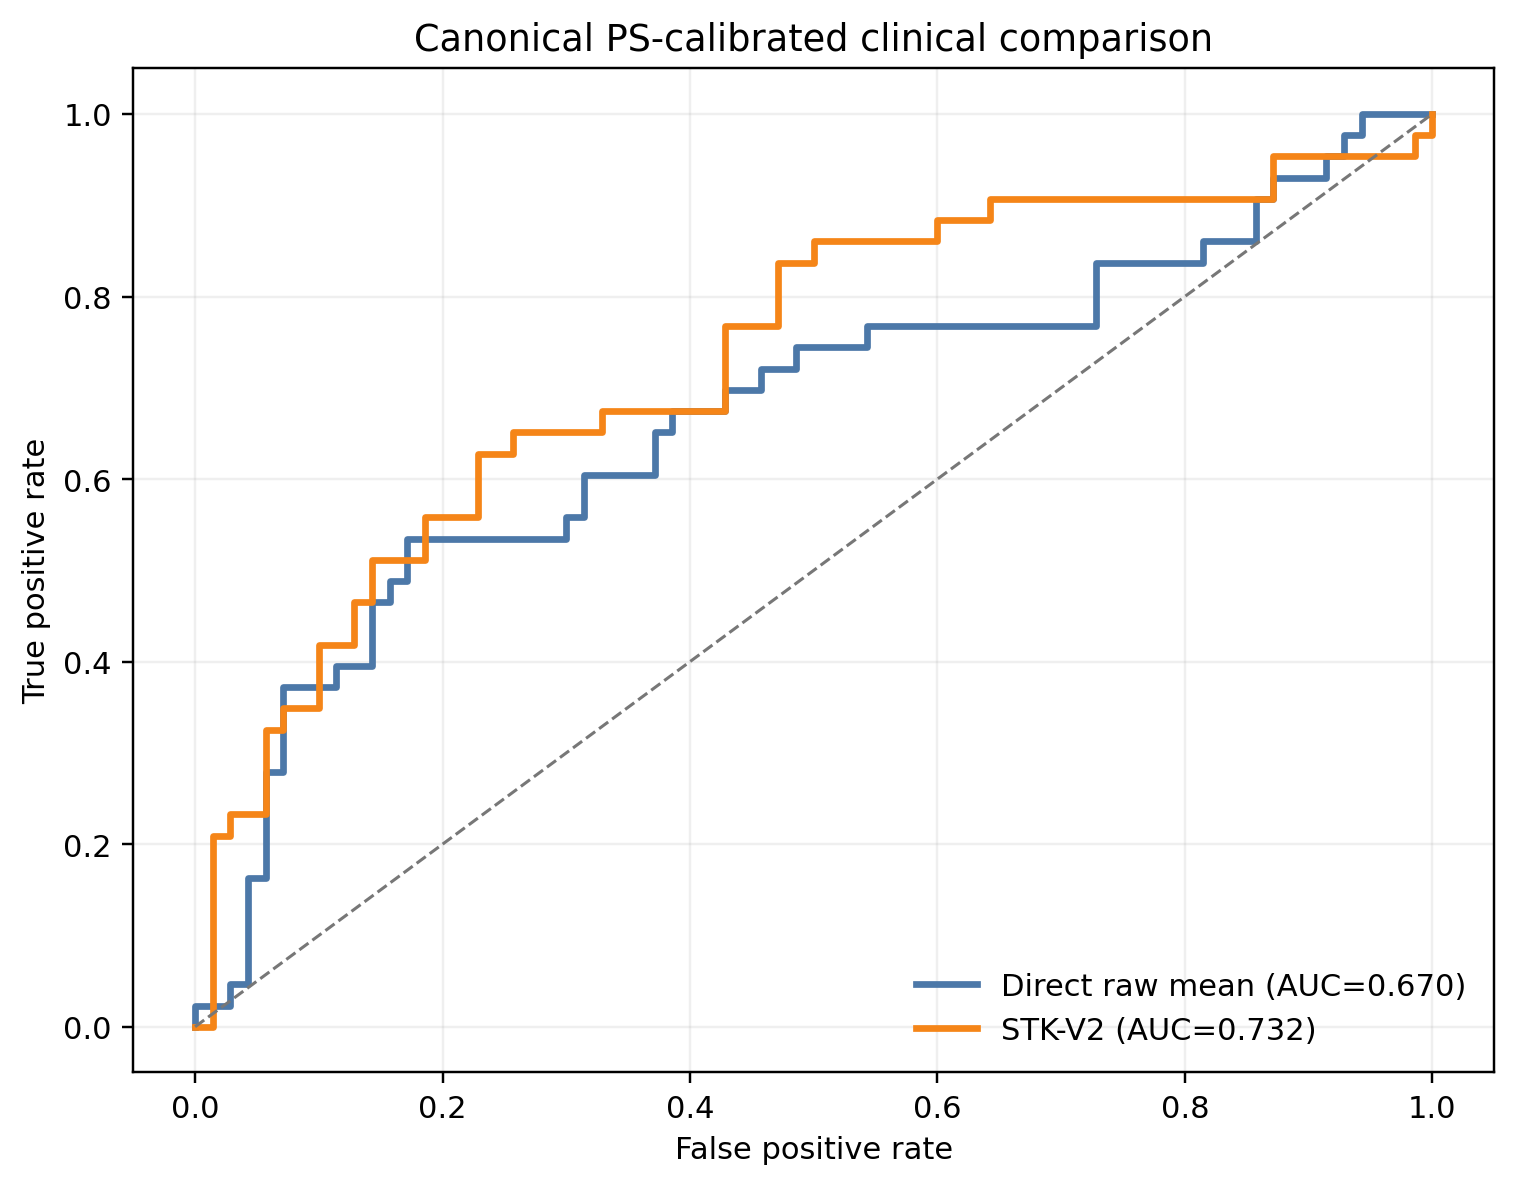

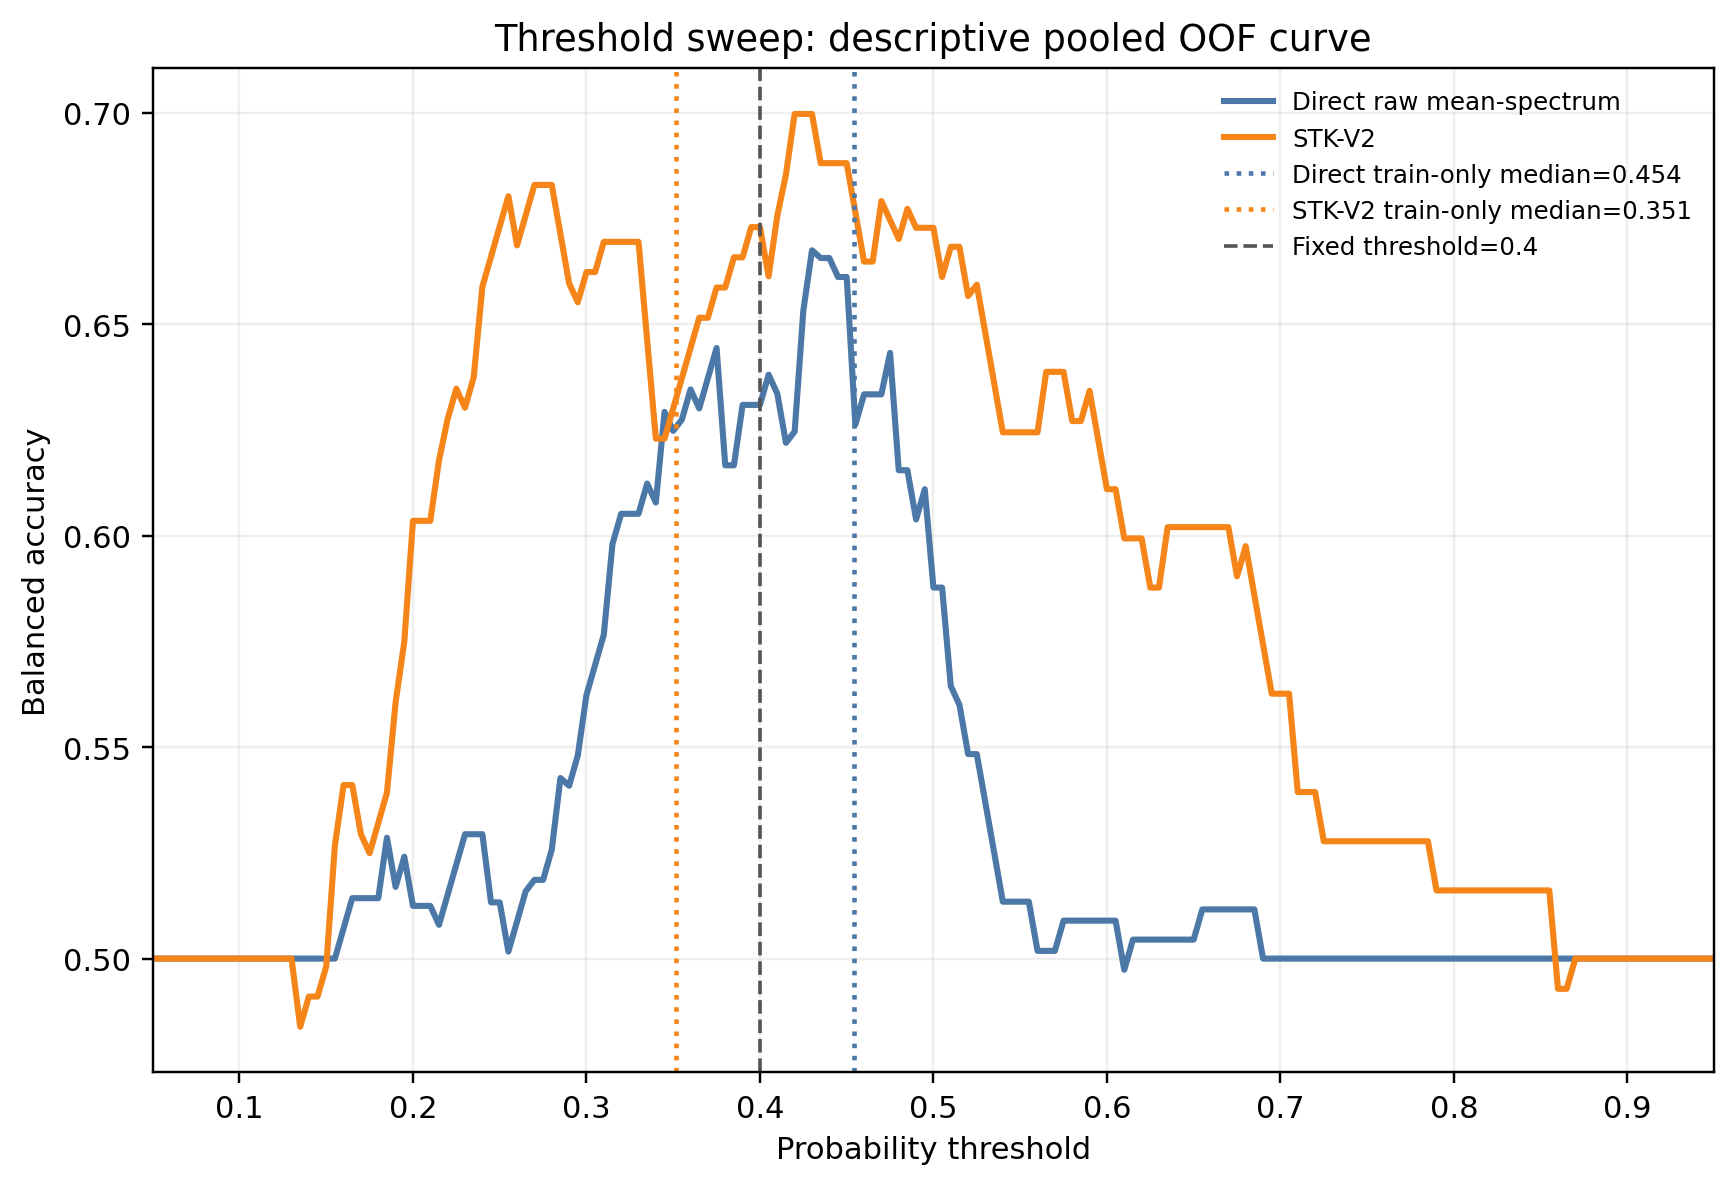

In [10]:
direct_fpr, direct_tpr, _ = roc_curve(
    direct_y,
    direct_probability,
)
stk_fpr, stk_tpr, _ = roc_curve(
    stk_y,
    stk_oof_probability,
)
direct_auc = roc_auc_score(direct_y, direct_probability)
stk_auc = roc_auc_score(stk_y, stk_oof_probability)

fig, axis = plt.subplots(figsize=(7, 5.5))
axis.plot(
    direct_fpr,
    direct_tpr,
    color="#4c78a8",
    linewidth=2.2,
    label=f"Direct raw mean (AUC={direct_auc:.3f})",
)
axis.plot(
    stk_fpr,
    stk_tpr,
    color="#f58518",
    linewidth=2.2,
    label=f"STK-V2 (AUC={stk_auc:.3f})",
)
axis.plot([0, 1], [0, 1], "--", color="#777777", linewidth=1)
axis.set(
    title="Canonical PS-calibrated clinical comparison",
    xlabel="False positive rate",
    ylabel="True positive rate",
)
axis.legend(loc="lower right", frameon=False)
axis.grid(alpha=0.2)
fig.tight_layout()
roc_comparison_path = FIGURE_DIR / "raw_mean_vs_stkv2_roc.png"
fig.savefig(roc_comparison_path, dpi=220, bbox_inches="tight")
plt.close(fig)

fig, axis = plt.subplots(figsize=(8, 5.5))
for model_name, color in [
    ("Direct raw mean-spectrum", "#4c78a8"),
    ("STK-V2", "#f58518"),
]:
    frame = threshold_sweep_frame.loc[
        threshold_sweep_frame["model"].eq(model_name)
    ]
    axis.plot(
        frame["threshold"],
        frame["balanced_accuracy"],
        color=color,
        linewidth=2.0,
        label=model_name,
    )
axis.axvline(
    direct_tuned_threshold,
    color="#4c78a8",
    linestyle=":",
    linewidth=1.5,
    label=f"Direct train-only median={direct_tuned_threshold:.3f}",
)
axis.axvline(
    stk_threshold_median,
    color="#f58518",
    linestyle=":",
    linewidth=1.5,
    label=f"STK-V2 train-only median={stk_threshold_median:.3f}",
)
axis.axvline(
    0.4,
    color="#555555",
    linestyle="--",
    linewidth=1.2,
    label="Fixed threshold=0.4",
)
axis.set(
    title="Threshold sweep: descriptive pooled OOF curve",
    xlabel="Probability threshold",
    ylabel="Balanced accuracy",
)
axis.set_xlim(0.05, 0.95)
axis.grid(alpha=0.2)
axis.legend(loc="best", frameon=False, fontsize=8)
fig.tight_layout()
threshold_comparison_path = FIGURE_DIR / "threshold_sweep_comparison.png"
fig.savefig(threshold_comparison_path, dpi=220, bbox_inches="tight")
plt.close(fig)

publication_dir = REPO_ROOT / "publications/전향검체/보라매병원/figures/mean_spectrum"
publication_dir.mkdir(parents=True, exist_ok=True)
shutil.copy2(
    roc_comparison_path,
    publication_dir / "fig12_mean_spectrum_raw_vs_stkv2_roc.png",
)
shutil.copy2(
    threshold_comparison_path,
    publication_dir / "fig13_mean_spectrum_threshold_sweep.png",
)
display(Image(filename=str(roc_comparison_path)))
display(Image(filename=str(threshold_comparison_path)))

### 7. Screening OOF metrics

,model,threshold,threshold_policy,roc_auc,balanced_accuracy,sensitivity,specificity,true_negative,false_positive,false_negative,true_positive
0,Direct raw mean-spectrum,0.454468,outer-train inner-meta OOF balanced-accuracy o...,0.669767,0.622757,0.488372,0.757143,53,17,22,21
1,STK-V2,0.351486,outer-train inner-meta OOF balanced-accuracy o...,0.731561,0.586213,0.558140,0.614286,43,27,19,24


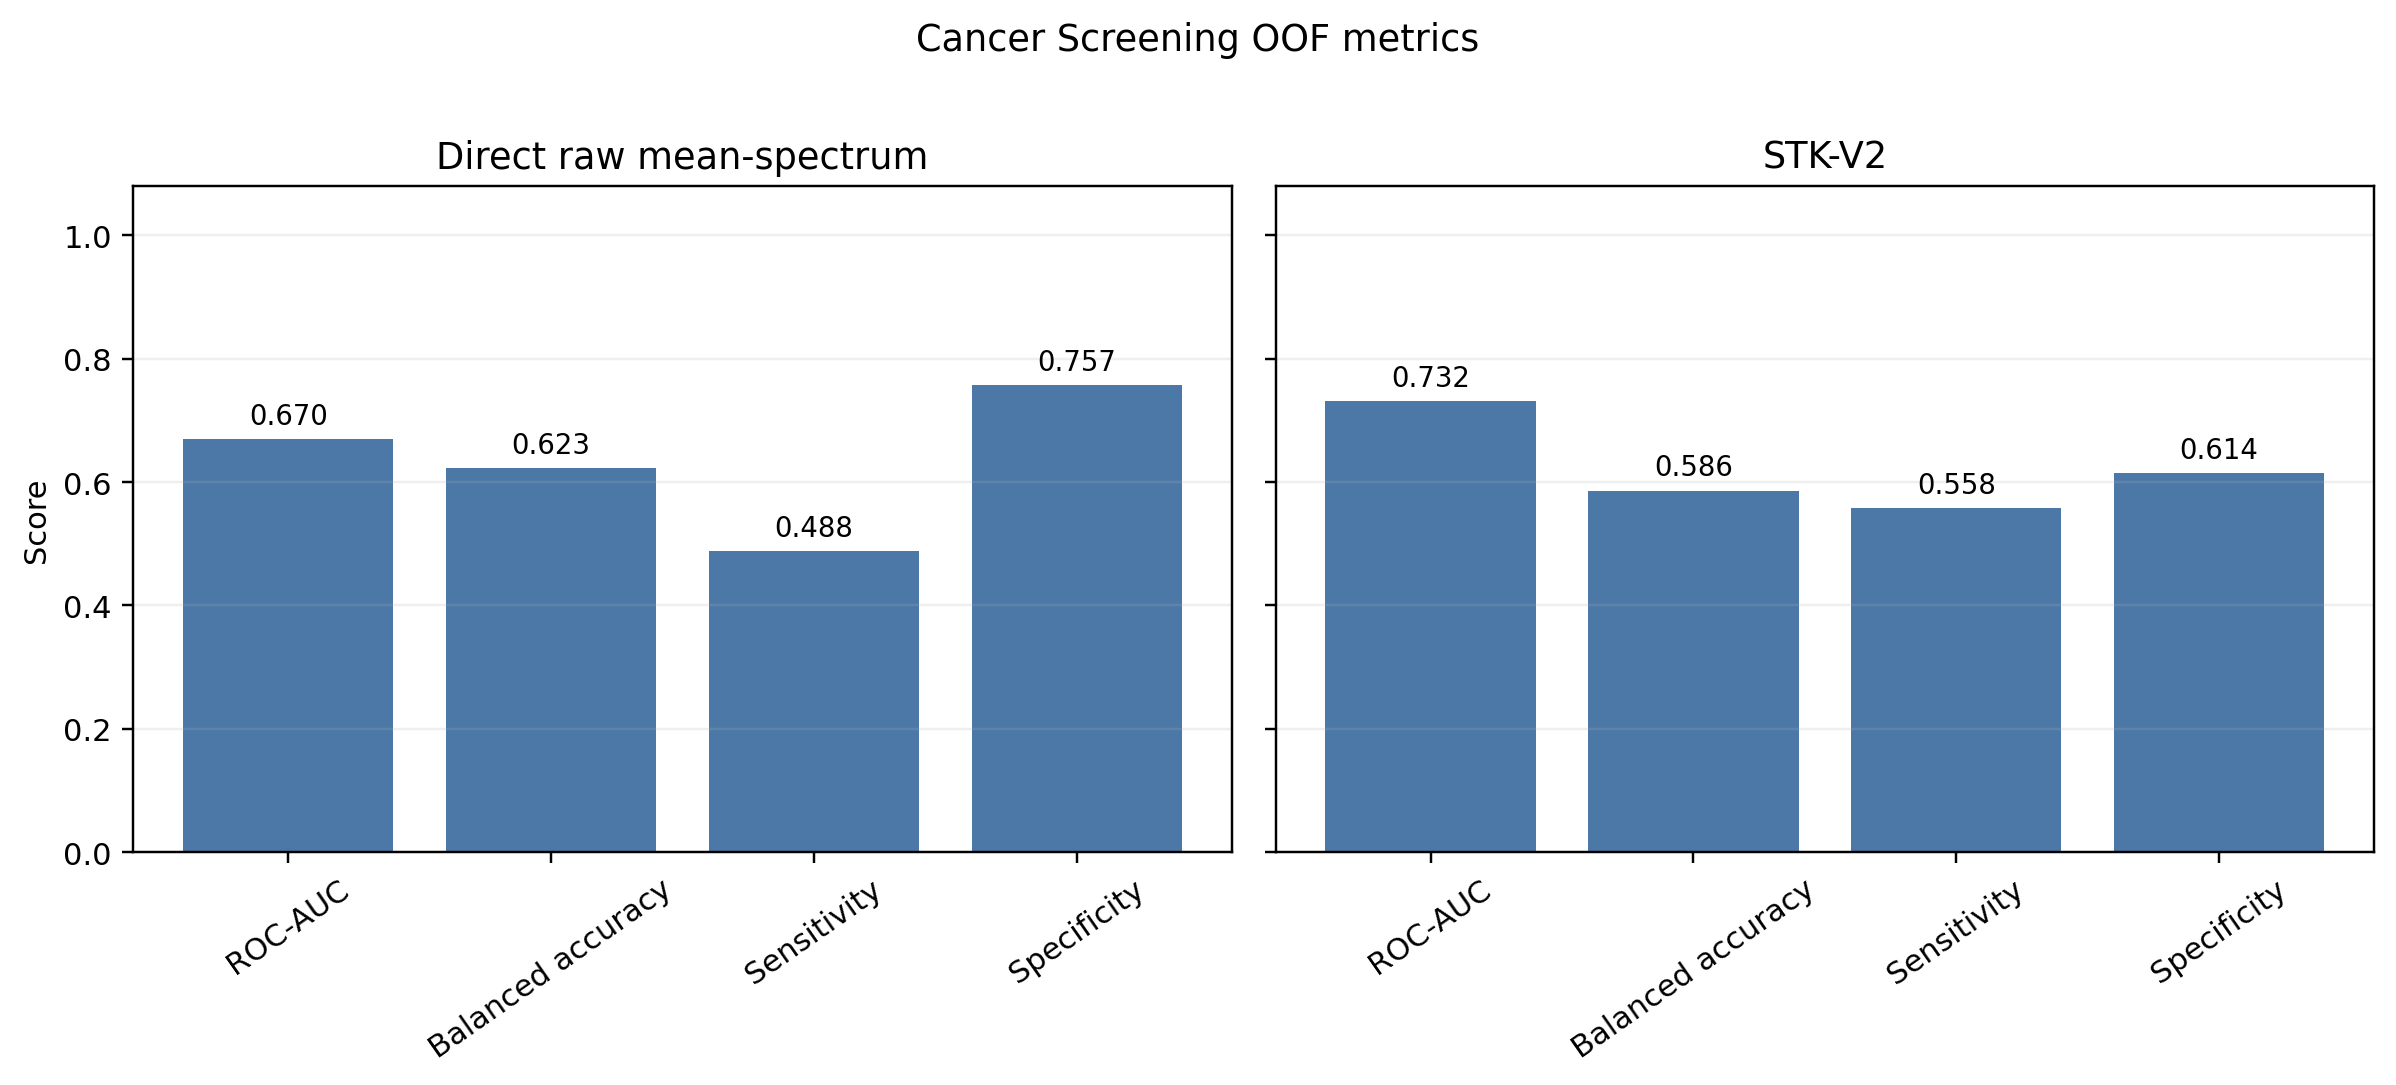

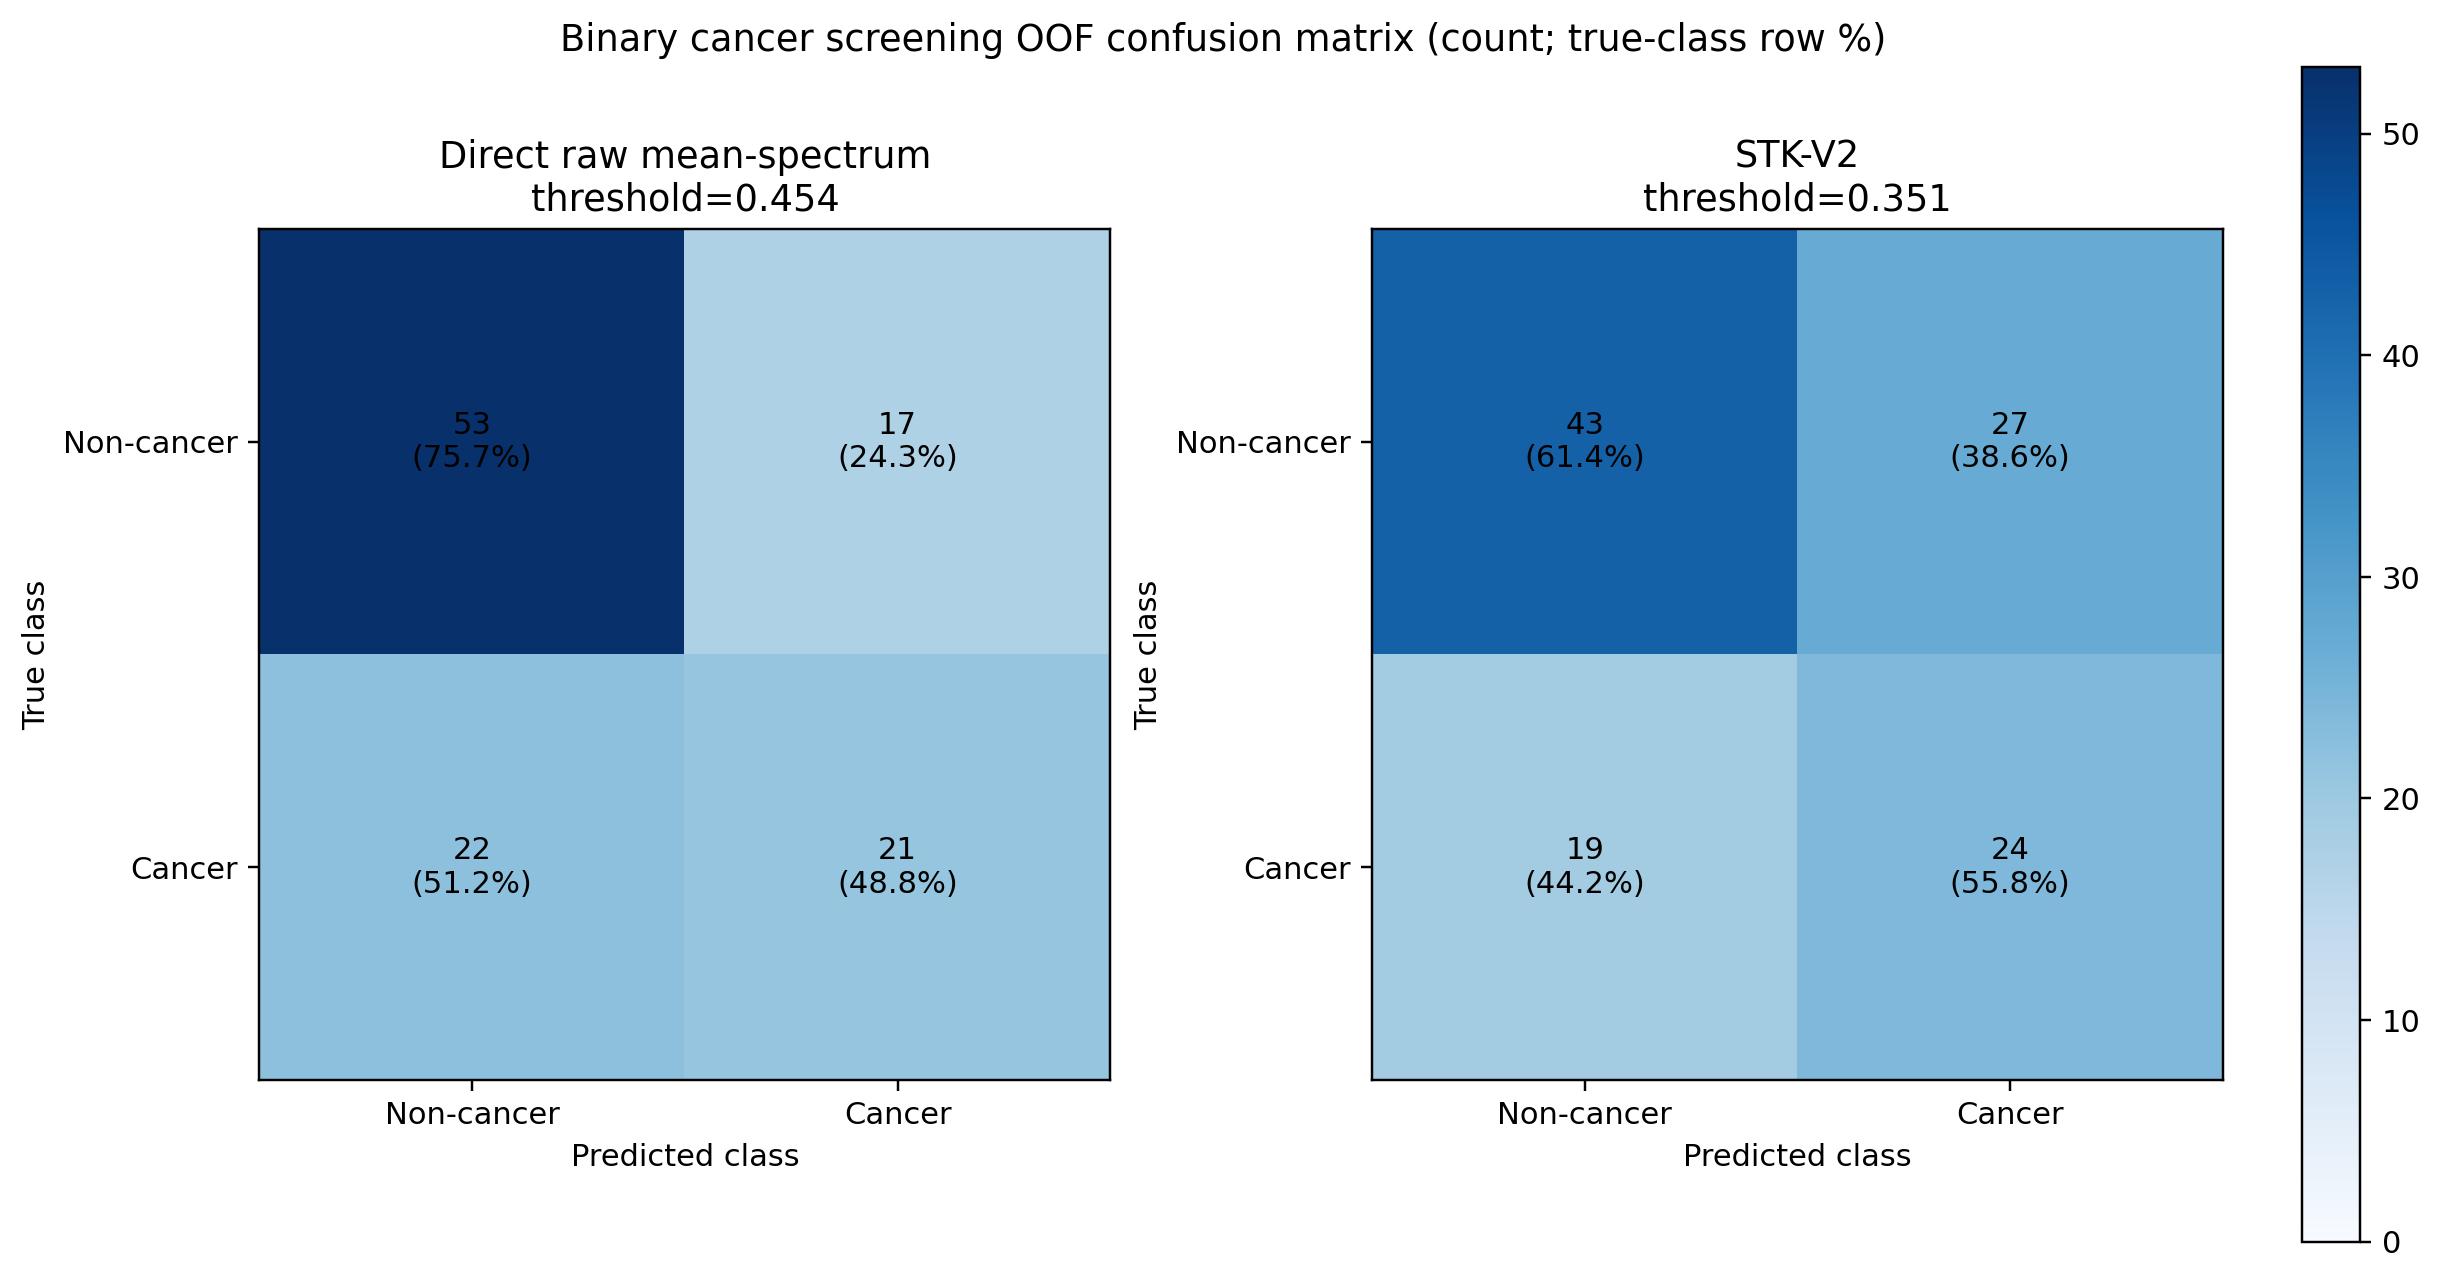

In [11]:
from sklearn.metrics import confusion_matrix, recall_score, roc_auc_score

screening_specs = [
    {
        "model": "Direct raw mean-spectrum",
        "threshold": direct_tuned_threshold,
        "policy": str(performance["threshold_policy"].iloc[0]),
        "y_true": direct_y,
        "probability": direct_probability,
        "prediction": direct_tuned_prediction,
    },
    {
        "model": "STK-V2",
        "threshold": stk_threshold_median,
        "policy": "outer-train inner-meta OOF balanced-accuracy optimum",
        "y_true": stk_y,
        "probability": stk_oof_probability,
        "prediction": stk_oof_prediction,
    },
]
screening_metric_rows = []
for spec in screening_specs:
    tn, fp, fn, tp = confusion_matrix(
        spec["y_true"],
        spec["prediction"],
        labels=[0, 1],
    ).ravel()
    screening_metric_rows.append({
        "model": spec["model"],
        "threshold": float(spec["threshold"]),
        "threshold_policy": spec["policy"],
        "roc_auc": float(
            roc_auc_score(spec["y_true"], spec["probability"])
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(spec["y_true"], spec["prediction"])
        ),
        "sensitivity": float(
            recall_score(spec["y_true"], spec["prediction"], zero_division=0)
        ),
        "specificity": float(tn / (tn + fp)),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    })
screening_oof_metrics = pd.DataFrame(screening_metric_rows)
screening_oof_metrics.to_csv(
    OUTPUT_DIR / "screening_oof_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
display(screening_oof_metrics)

metric_names = ["roc_auc", "balanced_accuracy", "sensitivity", "specificity"]
metric_labels = ["ROC-AUC", "Balanced accuracy", "Sensitivity", "Specificity"]
bar_color = "#4c78a8"
fig, axes = plt.subplots(
    1,
    len(screening_oof_metrics),
    figsize=(11, 4.8),
    sharey=True,
)
for axis, (_, row) in zip(axes, screening_oof_metrics.iterrows()):
    values = [float(row[name]) for name in metric_names]
    bars = axis.bar(metric_labels, values, color=bar_color)
    axis.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    axis.set_title(str(row["model"]))
    axis.set_ylim(0, 1.08)
    axis.tick_params(axis="x", rotation=35)
    axis.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Score")
fig.suptitle("Cancer Screening OOF metrics", y=1.02)
fig.tight_layout()
screening_metrics_path = FIGURE_DIR / "screening_oof_metrics.png"
fig.savefig(screening_metrics_path, dpi=220, bbox_inches="tight")
plt.close(fig)
shutil.copy2(
    screening_metrics_path,
    REPO_ROOT
    / "publications/전향검체/보라매병원/figures/mean_spectrum"
    / "fig14_mean_spectrum_screening_oof_metrics.png",
)
display(Image(filename=str(screening_metrics_path)))

binary_confusion_figure, binary_confusion_axes = plt.subplots(
    1,
    len(screening_specs),
    figsize=(11, 5.5),
    constrained_layout=True,
)
binary_confusion_matrices = []
for axis, spec in zip(binary_confusion_axes, screening_specs):
    matrix = confusion_matrix(
        spec["y_true"],
        spec["prediction"],
        labels=[0, 1],
    )
    binary_confusion_matrices.append(matrix)
binary_confusion_maximum = max(
    int(matrix.max()) for matrix in binary_confusion_matrices
)
for axis, spec, matrix in zip(
    binary_confusion_axes,
    screening_specs,
    binary_confusion_matrices,
):
    row_totals = matrix.sum(axis=1, keepdims=True)
    row_percentages = np.divide(
        matrix,
        row_totals,
        out=np.zeros_like(matrix, dtype=float),
        where=row_totals != 0,
    )
    image = axis.imshow(
        matrix,
        cmap="Blues",
        vmin=0,
        vmax=binary_confusion_maximum,
    )
    for row in range(2):
        for column in range(2):
            axis.text(
                column,
                row,
                f"{int(matrix[row, column])}\n"
                f"({row_percentages[row, column]:.1%})",
                ha="center",
                va="center",
            )
    axis.set(
        xticks=[0, 1],
        yticks=[0, 1],
        xticklabels=["Non-cancer", "Cancer"],
        yticklabels=["Non-cancer", "Cancer"],
        xlabel="Predicted class",
        ylabel="True class",
        title=(
            f"{spec['model']}\n"
            f"threshold={spec['threshold']:.3f}"
        ),
    )
    axis.tick_params(axis="x", rotation=0)
binary_confusion_figure.colorbar(
    image,
    ax=binary_confusion_axes.ravel().tolist(),
    fraction=0.046,
    pad=0.04,
)
binary_confusion_figure.suptitle(
    "Binary cancer screening OOF confusion matrix (count; true-class row %)",
    y=1.03,
)
binary_confusion_path = FIGURE_DIR / "screening_confusion_comparison.png"
binary_confusion_figure.savefig(
    binary_confusion_path,
    dpi=220,
    bbox_inches="tight",
)
plt.close(binary_confusion_figure)
shutil.copy2(
    binary_confusion_path,
    REPO_ROOT
    / "publications/전향검체/보라매병원/figures/mean_spectrum"
    / "fig18_mean_spectrum_screening_confusion_comparison.png",
)
display(Image(filename=str(binary_confusion_path)))

### 8. Three-class OOF performance

In [12]:
from aecd_api_model_3class_engine import (
    CLASS_INDEX,
    CLASS_NAMES,
    run_nested_multiclass,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

three_class_labels = np.asarray(
    [CLASS_INDEX[label] for label in stk_labels],
    dtype=np.int64,
)
three_class_groups = np.arange(len(three_class_labels), dtype=np.int64)
three_class_count = len(CLASS_NAMES)

def make_three_class_logistic(c_value):
    def factory():
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=5000,
                C=c_value,
                random_state=analysis.RANDOM_STATE,
            ),
        )
    return factory

def make_three_class_xgb():
    return XGBClassifier(
        objective="multi:softprob",
        num_class=three_class_count,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=analysis.RANDOM_STATE,
        verbosity=0,
    )

def make_three_class_rf():
    return RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        n_jobs=-1,
        random_state=analysis.RANDOM_STATE,
    )

direct_three_specs = [
    ("lr_raw_mean", "raw", make_three_class_logistic(1.0)),
    ("xgb_raw_mean", "raw", make_three_class_xgb),
    ("rf_raw_mean", "raw", make_three_class_rf),
    ("ridge_raw_mean", "raw", make_three_class_logistic(0.1)),
]
stk_three_specs = [
    ("lr_raw", "raw", make_three_class_logistic(1.0)),
    ("lr_d1", "d1", make_three_class_logistic(1.0)),
    ("lr_d2", "d2", make_three_class_logistic(1.0)),
    ("lr_concat", "concat", make_three_class_logistic(1.0)),
    ("lr_peak", "peak", make_three_class_logistic(1.0)),
    ("xgb_raw", "raw", make_three_class_xgb),
    ("xgb_d1", "d1", make_three_class_xgb),
    ("rf_raw", "raw", make_three_class_rf),
    ("rf_d1", "d1", make_three_class_rf),
    ("ridge_concat", "concat", make_three_class_logistic(0.1)),
]
direct_three_views = {"raw": stk_raw_means}
three_class_runs = {}
for model_name, views, base_specs in [
    ("Direct raw mean-spectrum", direct_three_views, direct_three_specs),
    ("STK-V2", stk_views, stk_three_specs),
]:
    probabilities, fold_rows = run_nested_multiclass(
        views,
        three_class_labels,
        three_class_groups,
        base_specs,
    )
    three_class_runs[model_name] = {
        "probability": probabilities,
        "fold_rows": fold_rows,
    }
    print(
        model_name,
        {
            "subjects": len(three_class_labels),
            "classes": dict(
                zip(
                    CLASS_NAMES,
                    np.bincount(
                        three_class_labels,
                        minlength=three_class_count,
                    ),
                )
            ),
        },
    )

Direct raw mean-spectrum {'subjects': 113, 'classes': {'control': np.int64(21), 'prostate disease control': np.int64(49), 'prostate': np.int64(43)}}


STK-V2 {'subjects': 113, 'classes': {'control': np.int64(21), 'prostate disease control': np.int64(49), 'prostate': np.int64(43)}}


,model,evaluation_unit,subjects,macro_ovr_auc,weighted_ovr_auc,fold_macro_ovr_auc_mean,fold_macro_ovr_auc_std,balanced_accuracy,macro_f1,macro_sensitivity,macro_specificity,control_ovr_auc,control_sensitivity,control_specificity,prostate disease control_ovr_auc,prostate disease control_sensitivity,prostate disease control_specificity,prostate_ovr_auc,prostate_sensitivity,prostate_specificity
0,Direct raw mean-spectrum,subject-mean,113,0.561574,0.596855,0.590232,0.149659,0.413384,0.37639,0.413384,0.724249,0.391304,0.0,0.967391,0.601722,0.612245,0.5625,0.691694,0.627907,0.642857
1,STK-V2,subject-mean,113,0.621006,0.623345,0.635130,0.080539,0.410536,0.37076,0.410536,0.720186,0.598344,0.0,0.989130,0.581952,0.673469,0.5000,0.682724,0.558140,0.671429


,model,class_index,class_name,subjects,ovr_auc,sensitivity,specificity
0,Direct raw mean-spectrum,0,control,21,0.391304,0.000000,0.967391
1,Direct raw mean-spectrum,1,prostate disease control,49,0.601722,0.612245,0.562500
2,Direct raw mean-spectrum,2,prostate,43,0.691694,0.627907,0.642857
3,STK-V2,0,control,21,0.598344,0.000000,0.989130
4,STK-V2,1,prostate disease control,49,0.581952,0.673469,0.500000
5,STK-V2,2,prostate,43,0.682724,0.558140,0.671429


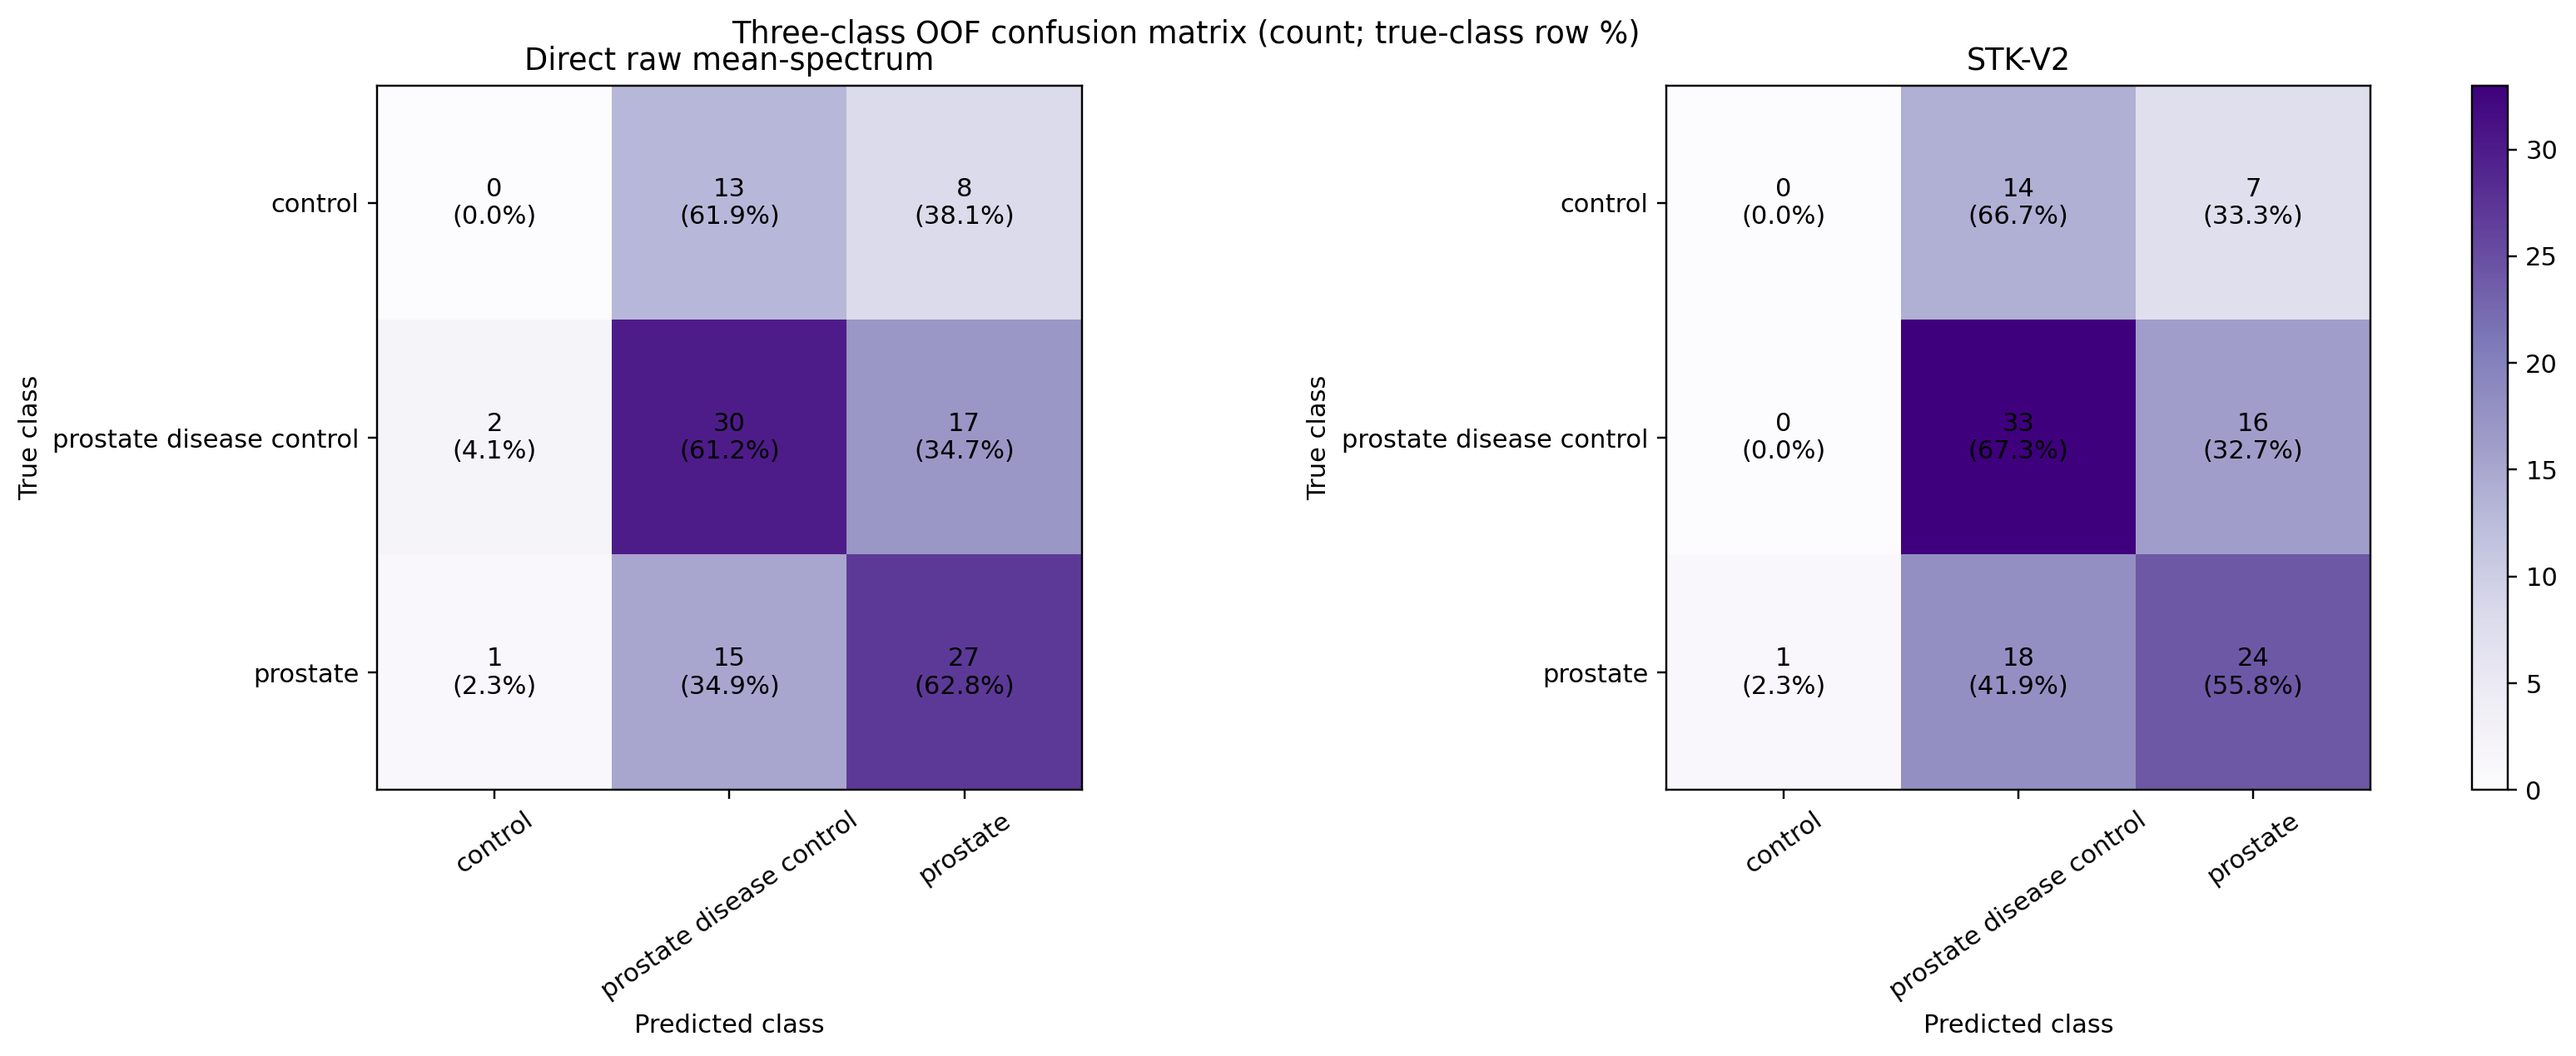

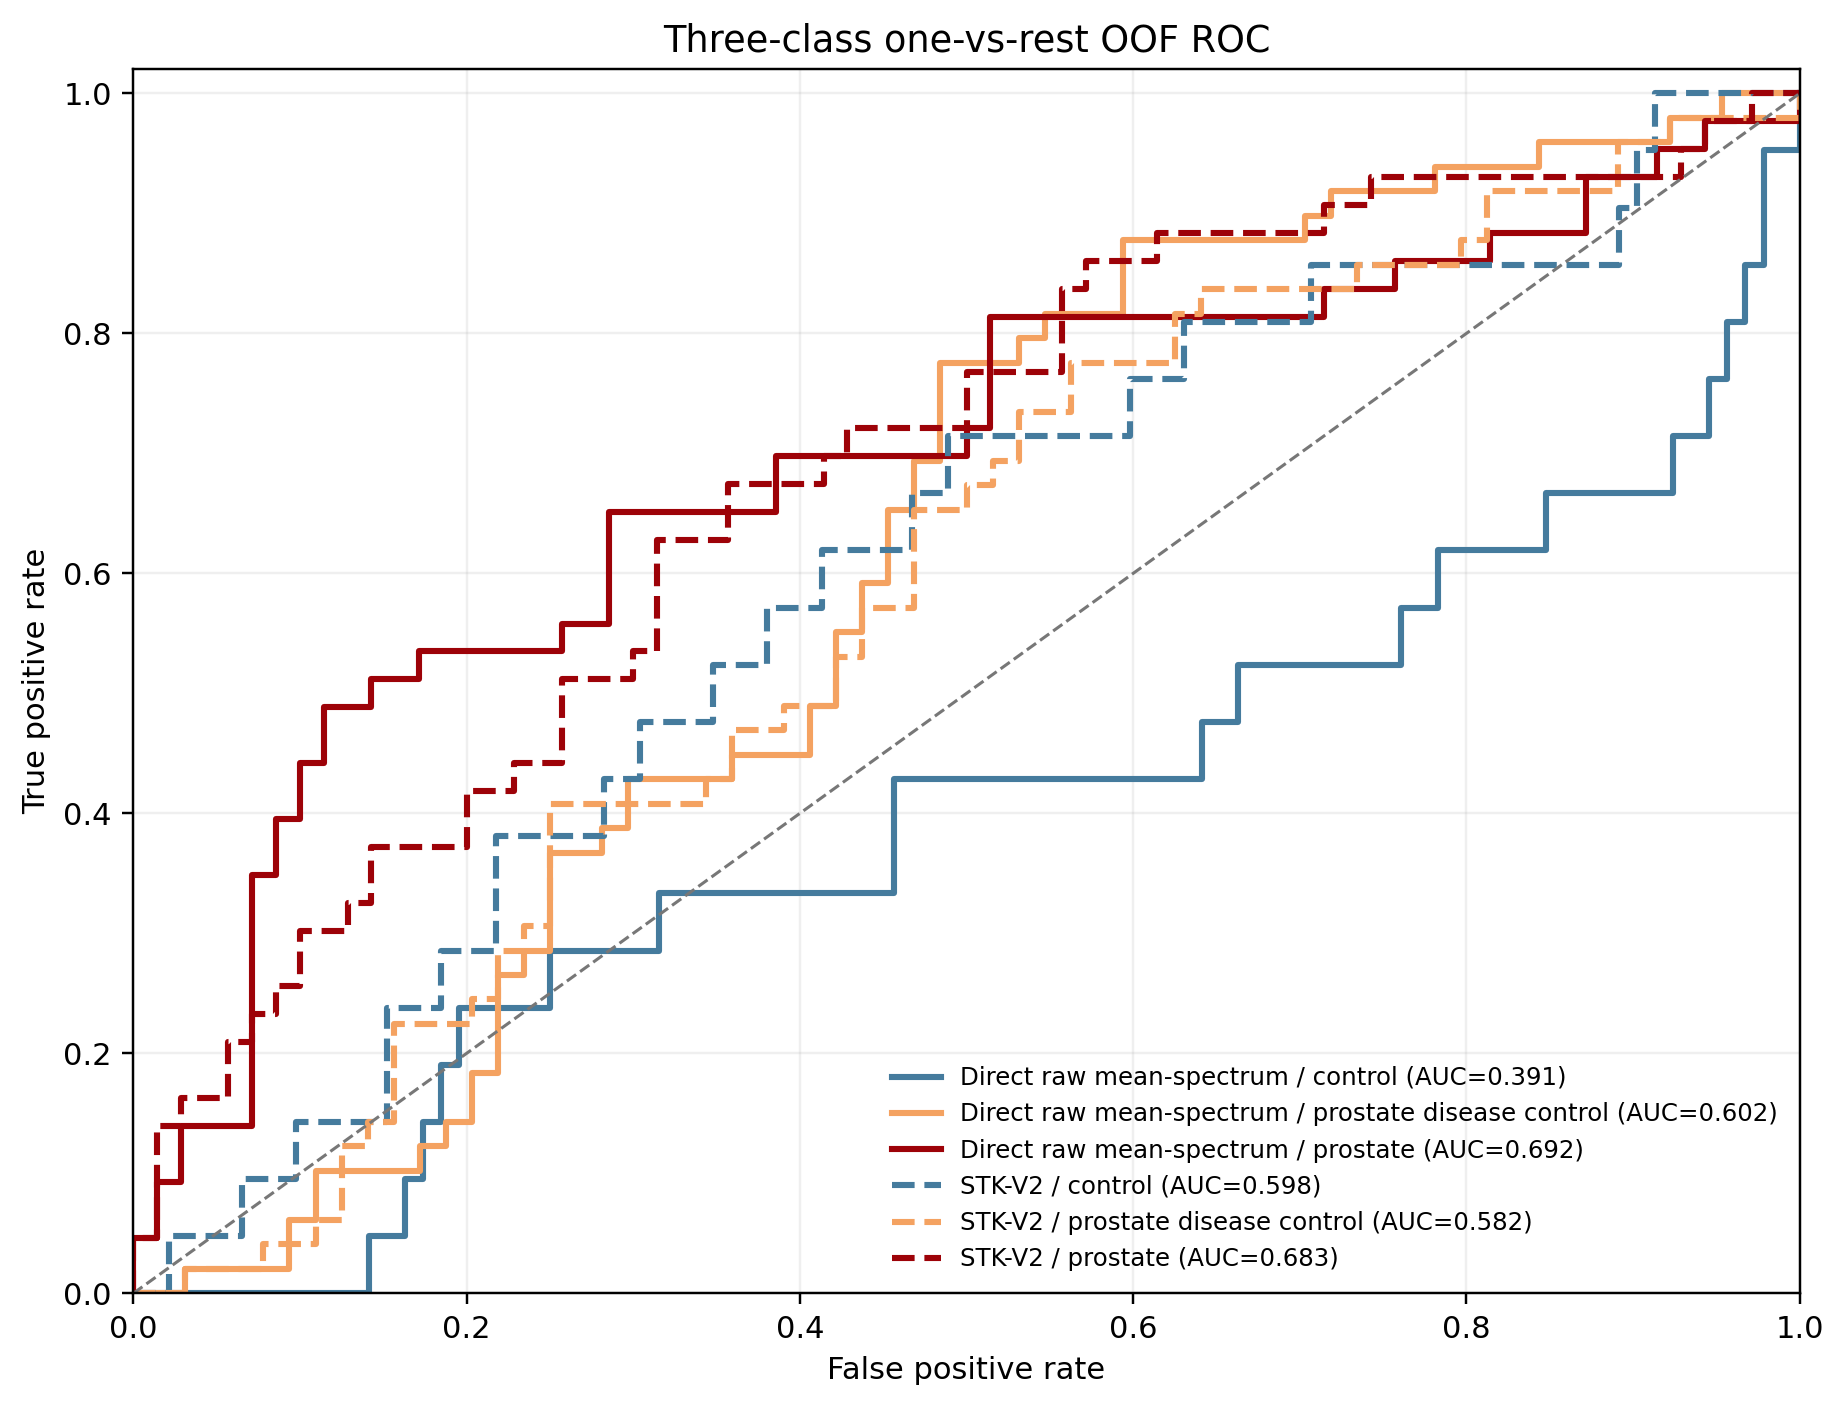

,model,macro_ovr_auc,balanced_accuracy,macro_sensitivity,macro_specificity,macro_f1
0,Direct raw mean-spectrum,0.561574,0.413384,0.413384,0.724249,0.37639
1,STK-V2,0.621006,0.410536,0.410536,0.720186,0.37076


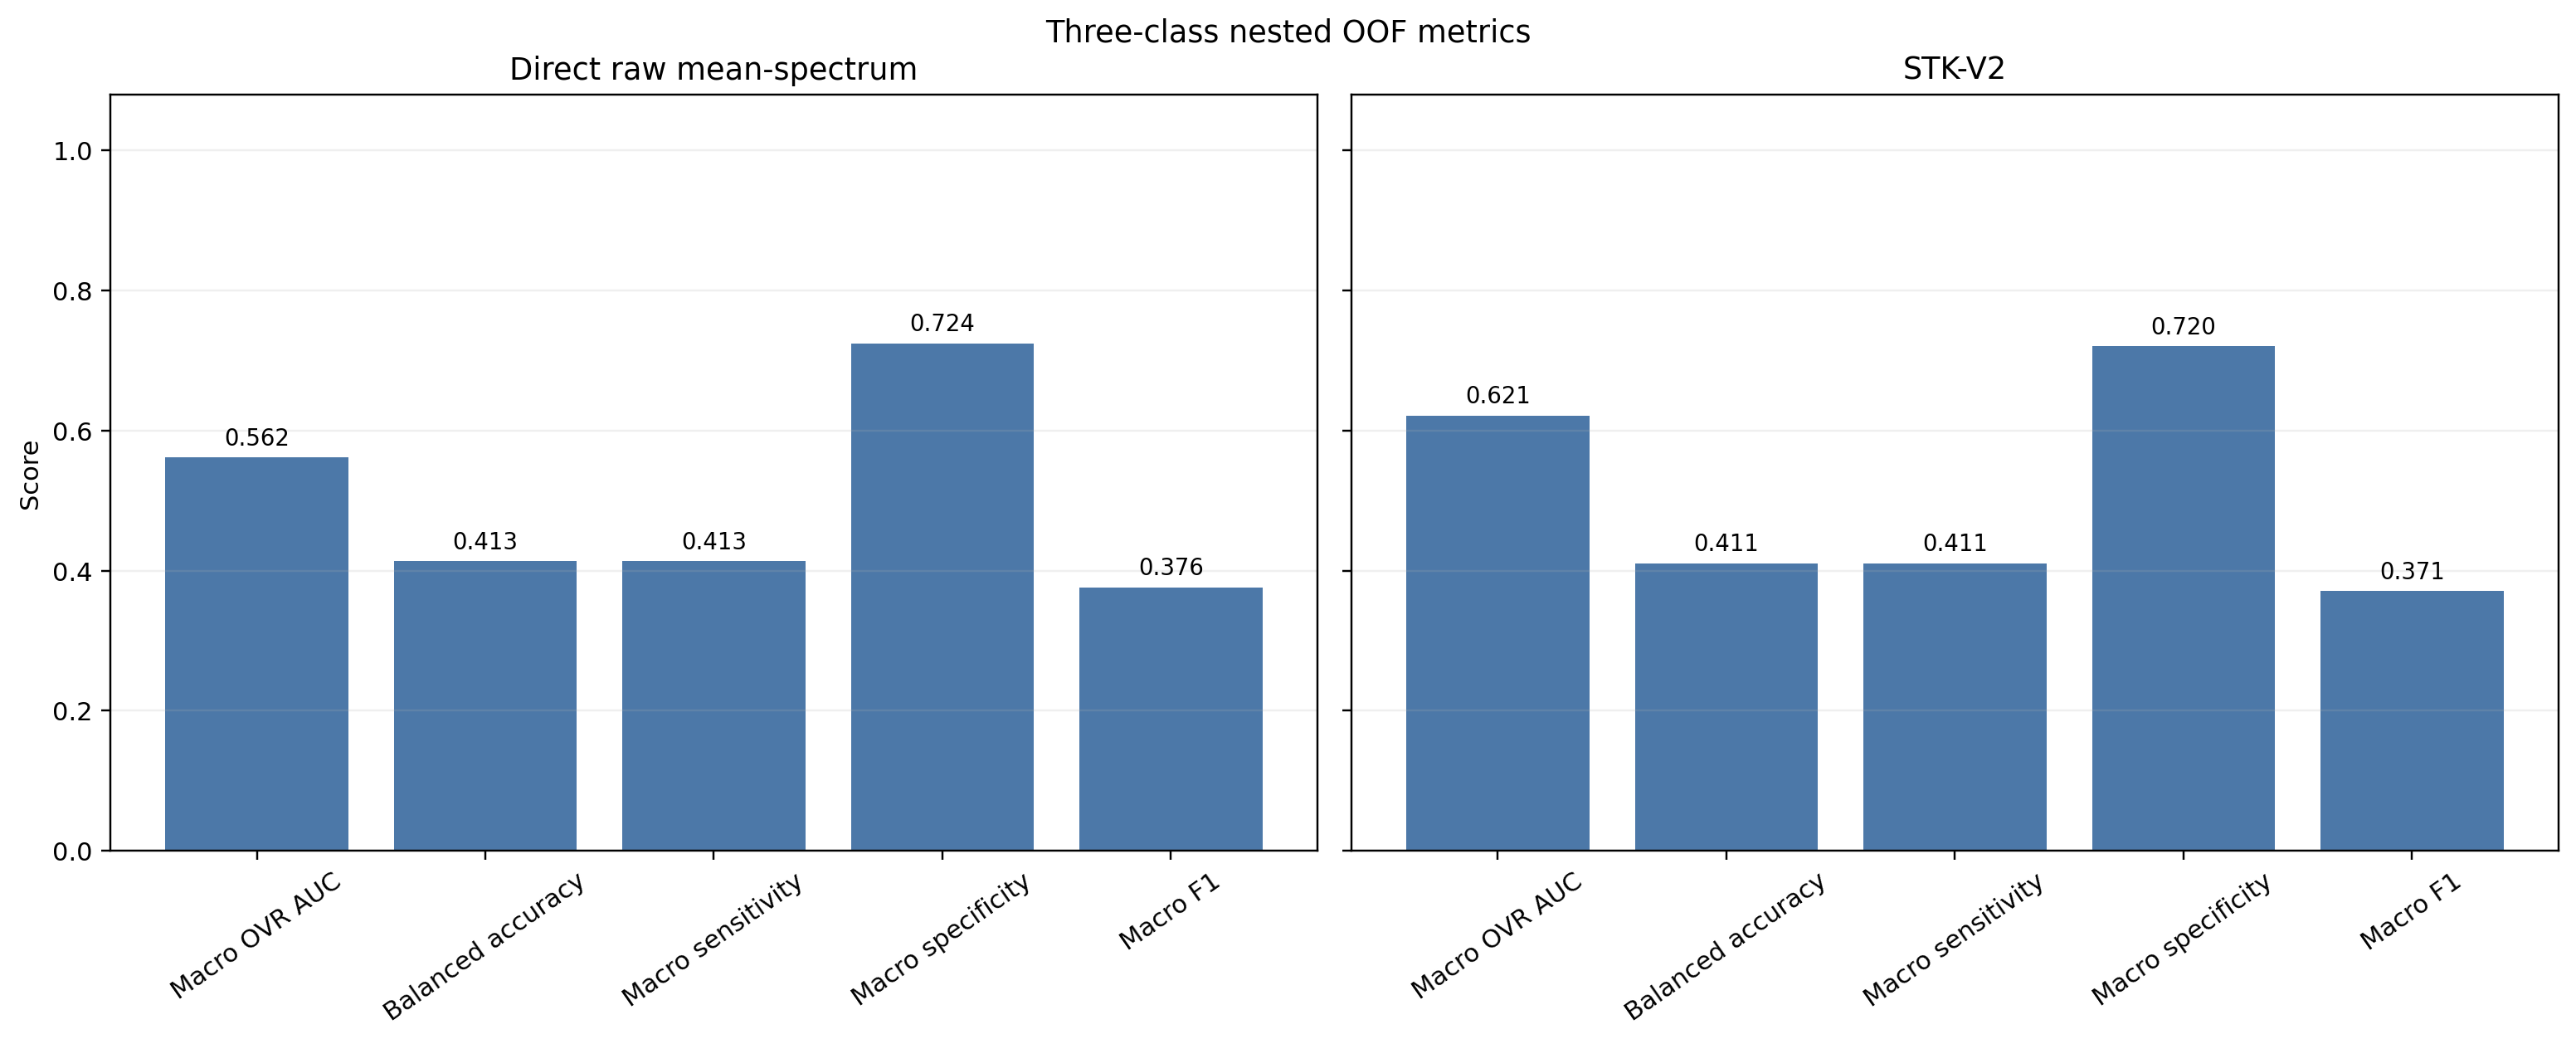

In [13]:
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    multilabel_confusion_matrix,
    roc_auc_score,
    roc_curve,
)

def summarize_three_class(model_name, probability, fold_rows):
    prediction = np.argmax(probability, axis=1)
    confusion = confusion_matrix(
        three_class_labels,
        prediction,
        labels=np.arange(three_class_count),
    )
    class_confusion = multilabel_confusion_matrix(
        three_class_labels,
        prediction,
        labels=np.arange(three_class_count),
    )
    true_positive = class_confusion[:, 1, 1].astype(float)
    false_negative = class_confusion[:, 1, 0].astype(float)
    true_negative = class_confusion[:, 0, 0].astype(float)
    false_positive = class_confusion[:, 0, 1].astype(float)
    sensitivity = np.divide(
        true_positive,
        true_positive + false_negative,
        out=np.zeros(three_class_count, dtype=float),
        where=(true_positive + false_negative) != 0,
    )
    specificity = np.divide(
        true_negative,
        true_negative + false_positive,
        out=np.zeros(three_class_count, dtype=float),
        where=(true_negative + false_positive) != 0,
    )
    class_auc = roc_auc_score(
        three_class_labels,
        probability,
        multi_class="ovr",
        average=None,
        labels=np.arange(three_class_count),
    )
    summary = {
        "model": model_name,
        "evaluation_unit": "subject-mean",
        "subjects": int(len(three_class_labels)),
        "macro_ovr_auc": float(
            roc_auc_score(
                three_class_labels,
                probability,
                multi_class="ovr",
                average="macro",
                labels=np.arange(three_class_count),
            )
        ),
        "weighted_ovr_auc": float(
            roc_auc_score(
                three_class_labels,
                probability,
                multi_class="ovr",
                average="weighted",
                labels=np.arange(three_class_count),
            )
        ),
        "fold_macro_ovr_auc_mean": float(
            np.mean([row["macro_ovr_auc"] for row in fold_rows])
        ),
        "fold_macro_ovr_auc_std": float(
            np.std([row["macro_ovr_auc"] for row in fold_rows])
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(three_class_labels, prediction)
        ),
        "macro_f1": float(
            f1_score(
                three_class_labels,
                prediction,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_sensitivity": float(np.mean(sensitivity)),
        "macro_specificity": float(np.mean(specificity)),
    }
    class_rows = []
    confusion_rows = []
    class_counts = np.bincount(
        three_class_labels,
        minlength=three_class_count,
    )
    for class_index, class_name in enumerate(CLASS_NAMES):
        summary[f"{class_name}_ovr_auc"] = float(class_auc[class_index])
        summary[f"{class_name}_sensitivity"] = float(sensitivity[class_index])
        summary[f"{class_name}_specificity"] = float(specificity[class_index])
        class_rows.append({
            "model": model_name,
            "class_index": int(class_index),
            "class_name": class_name,
            "subjects": int(class_counts[class_index]),
            "ovr_auc": float(class_auc[class_index]),
            "sensitivity": float(sensitivity[class_index]),
            "specificity": float(specificity[class_index]),
        })
        row_total = int(confusion[class_index].sum())
        for predicted_index, count in enumerate(confusion[class_index]):
            confusion_rows.append({
                "model": model_name,
                "true_class": class_name,
                "predicted_class": CLASS_NAMES[predicted_index],
                "count": int(count),
                "row_percentage": float(
                    count / row_total if row_total else 0.0
                ),
                "overall_percentage": float(
                    count / confusion.sum() if confusion.sum() else 0.0
                ),
            })
    return summary, class_rows, confusion_rows, confusion, prediction

three_class_summary_rows = []
three_class_class_rows = []
three_class_confusion_rows = []
three_class_fold_frames = []
three_class_oof_frames = []
three_class_artifacts = {}
for model_name, run in three_class_runs.items():
    summary, class_rows, confusion_rows, confusion, prediction = (
        summarize_three_class(
            model_name,
            run["probability"],
            run["fold_rows"],
        )
    )
    three_class_summary_rows.append(summary)
    three_class_class_rows.extend(class_rows)
    three_class_confusion_rows.extend(confusion_rows)
    fold_frame = pd.DataFrame(run["fold_rows"])
    fold_frame.insert(0, "model", model_name)
    three_class_fold_frames.append(fold_frame)
    probability = run["probability"]
    oof_frame = pd.DataFrame({
        "model": model_name,
        "subject_index_internal": np.arange(len(three_class_labels)),
        "true_class_index": three_class_labels,
        "true_class": [CLASS_NAMES[index] for index in three_class_labels],
        "predicted_class_index": prediction,
        "predicted_class": [CLASS_NAMES[index] for index in prediction],
    })
    for class_index, class_name in enumerate(CLASS_NAMES):
        oof_frame[f"probability_{class_name}"] = probability[:, class_index]
    three_class_oof_frames.append(oof_frame)
    three_class_artifacts[model_name] = {
        "probability": probability,
        "confusion": confusion,
    }

three_class_performance = pd.DataFrame(three_class_summary_rows)
three_class_class_metrics = pd.DataFrame(three_class_class_rows)
three_class_confusion_metrics = pd.DataFrame(three_class_confusion_rows)
three_class_fold_metrics = pd.concat(
    three_class_fold_frames,
    ignore_index=True,
)
three_class_oof_predictions = pd.concat(
    three_class_oof_frames,
    ignore_index=True,
)
three_class_performance.to_csv(
    OUTPUT_DIR / "three_class_performance_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
three_class_class_metrics.to_csv(
    OUTPUT_DIR / "three_class_class_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
three_class_confusion_metrics.to_csv(
    OUTPUT_DIR / "three_class_confusion_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
three_class_fold_metrics.to_csv(
    OUTPUT_DIR / "three_class_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
three_class_oof_predictions.to_csv(
    OUTPUT_DIR / "three_class_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)
three_class_metadata = {
    "classes": list(CLASS_NAMES),
    "class_counts": {
        name: int(count)
        for name, count in zip(
            CLASS_NAMES,
            np.bincount(
                three_class_labels,
                minlength=three_class_count,
            ),
        )
    },
    "subjects": int(len(three_class_labels)),
    "input": "PS-aligned, repeat-QC-passed subject mean spectrum",
    "direct_post_mean_preprocessing": [],
    "stk_v2_post_mean_preprocessing": [
        "400-2200 cm-1 crop",
        "fixed-grid interpolation",
        "Savitzky-Golay/baseline/SNV views",
        "first and second derivative views",
        "fixed peak features",
    ],
    "evaluation": "subject-level nested GroupKFold(outer=5, inner=5); argmax class probability",
}
(OUTPUT_DIR / "three_class_run_metadata.json").write_text(
    json.dumps(three_class_metadata, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
display(three_class_performance)
display(three_class_class_metrics)

def plot_three_class_confusions(artifacts, path):
    figure, axes = plt.subplots(
        1,
        len(artifacts),
        figsize=(15, 5.5),
        constrained_layout=True,
    )
    maximum = max(
        int(artifact["confusion"].max())
        for artifact in artifacts.values()
    )
    for axis, (model_name, artifact) in zip(axes, artifacts.items()):
        matrix = artifact["confusion"]
        row_totals = matrix.sum(axis=1, keepdims=True)
        row_percentages = np.divide(
            matrix,
            row_totals,
            out=np.zeros_like(matrix, dtype=float),
            where=row_totals != 0,
        )
        image = axis.imshow(
            matrix,
            cmap="Purples",
            vmin=0,
            vmax=maximum,
        )
        for row in range(three_class_count):
            for column in range(three_class_count):
                axis.text(
                    column,
                    row,
                    f"{int(matrix[row, column])}\n"
                    f"({row_percentages[row, column]:.1%})",
                    ha="center",
                    va="center",
                )
        axis.set(
            xticks=np.arange(three_class_count),
            yticks=np.arange(three_class_count),
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            xlabel="Predicted class",
            ylabel="True class",
            title=model_name,
        )
        axis.tick_params(axis="x", rotation=35)
    figure.colorbar(image, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    figure.suptitle(
        "Three-class OOF confusion matrix (count; true-class row %)",
        y=1.02,
    )
    figure.savefig(path, dpi=220, bbox_inches="tight")
    plt.close(figure)

def plot_three_class_roc(artifacts, path):
    class_colors = ["#457b9d", "#f4a261", "#9d0208"]
    model_styles = {
        "Direct raw mean-spectrum": "-",
        "STK-V2": "--",
    }
    figure, axis = plt.subplots(figsize=(8.5, 6.5))
    for model_name, artifact in artifacts.items():
        probability = artifact["probability"]
        for class_index, class_name in enumerate(CLASS_NAMES):
            false_positive_rate, true_positive_rate, _ = roc_curve(
                three_class_labels == class_index,
                probability[:, class_index],
            )
            class_auc = roc_auc_score(
                three_class_labels == class_index,
                probability[:, class_index],
            )
            axis.plot(
                false_positive_rate,
                true_positive_rate,
                color=class_colors[class_index],
                linestyle=model_styles[model_name],
                linewidth=2.0,
                label=f"{model_name} / {class_name} (AUC={class_auc:.3f})",
            )
    axis.plot([0, 1], [0, 1], "--", color="#777777", linewidth=1)
    axis.set(
        title="Three-class one-vs-rest OOF ROC",
        xlabel="False positive rate",
        ylabel="True positive rate",
        xlim=(0, 1),
        ylim=(0, 1.02),
    )
    axis.legend(loc="lower right", fontsize=8, frameon=False)
    axis.grid(alpha=0.2)
    figure.tight_layout()
    figure.savefig(path, dpi=220, bbox_inches="tight")
    plt.close(figure)

three_class_confusion_path = FIGURE_DIR / "three_class_confusion_comparison.png"
three_class_roc_path = FIGURE_DIR / "three_class_roc_comparison.png"
plot_three_class_confusions(three_class_artifacts, three_class_confusion_path)
plot_three_class_roc(three_class_artifacts, three_class_roc_path)
publication_dir = (
    REPO_ROOT / "publications/전향검체/보라매병원/figures/mean_spectrum"
)
shutil.copy2(
    three_class_confusion_path,
    publication_dir / "fig15_mean_spectrum_three_class_confusion.png",
)
shutil.copy2(
    three_class_roc_path,
    publication_dir / "fig16_mean_spectrum_three_class_roc.png",
)
display(Image(filename=str(three_class_confusion_path)))
display(Image(filename=str(three_class_roc_path)))

three_class_metric_names = [
    "macro_ovr_auc",
    "balanced_accuracy",
    "macro_sensitivity",
    "macro_specificity",
    "macro_f1",
]
three_class_metric_labels = [
    "Macro OVR AUC",
    "Balanced accuracy",
    "Macro sensitivity",
    "Macro specificity",
    "Macro F1",
]
three_class_nested_oof_metrics = three_class_performance[
    ["model", *three_class_metric_names]
].copy()
three_class_nested_oof_metrics.to_csv(
    OUTPUT_DIR / "three_class_nested_oof_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
display(three_class_nested_oof_metrics)

figure, axes = plt.subplots(
    1,
    len(three_class_nested_oof_metrics),
    figsize=(14, 5.4),
    sharey=True,
    constrained_layout=True,
)
for axis, (_, row) in zip(
    axes,
    three_class_nested_oof_metrics.iterrows(),
):
    values = [float(row[name]) for name in three_class_metric_names]
    bars = axis.bar(
        three_class_metric_labels,
        values,
        color="#4c78a8",
    )
    axis.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    axis.set_title(str(row["model"]))
    axis.set_ylim(0, 1.08)
    axis.tick_params(axis="x", rotation=35)
    axis.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Score")
figure.suptitle("Three-class nested OOF metrics", y=1.03)
three_class_metrics_path = FIGURE_DIR / "three_class_nested_oof_metrics.png"
figure.savefig(three_class_metrics_path, dpi=220, bbox_inches="tight")
plt.close(figure)
shutil.copy2(
    three_class_metrics_path,
    publication_dir / "fig17_mean_spectrum_three_class_nested_oof_metrics.png",
)
display(Image(filename=str(three_class_metrics_path)))

### 9. Figure gallery and output manifest

In [14]:
publication_dir = REPO_ROOT / "publications/전향검체/보라매병원/figures/mean_spectrum"
figure_specs = {
    "clinical_roc": (
        "clinical_roc.png",
        "fig01_mean_spectrum_clinical_roc.png",
    ),
    "confusion_matrix": (
        "confusion_matrix.png",
        "fig02_mean_spectrum_confusion_matrix.png",
    ),
    "representative_spectrum_and_noise": (
        "representative_spectrum_and_noise.png",
        "fig03_mean_spectrum_noise.png",
    ),
    "repeat_qc_pass_rate": (
        "repeat_qc_pass_rate.png",
        "fig04_mean_spectrum_qc.png",
    ),
    "snr_peak_summary": (
        "snr_peak_summary.png",
        "fig05_mean_spectrum_snr.png",
    ),
    "spectrum_noise_shading": (
        "spectrum_noise_shading.png",
        "fig06_mean_spectrum_signal_noise_shading.png",
    ),
    "signal_noise_band_validation": (
        "signal_noise_band_validation.png",
        "fig07_signal_noise_band_validation.png",
    ),
    "resolution_aware_peak_zoom": (
        "resolution_aware_peak_zoom.png",
        "fig08_resolution_aware_peak_zoom.png",
    ),
    "resolution_aware_snr_zoom": (
        "resolution_aware_snr_zoom.png",
        "fig09_resolution_aware_snr_zoom.png",
    ),
    "raw_mean_vs_stkv2_roc": (
        "raw_mean_vs_stkv2_roc.png",
        "fig12_mean_spectrum_raw_vs_stkv2_roc.png",
    ),
    "threshold_sweep_comparison": (
        "threshold_sweep_comparison.png",
        "fig13_mean_spectrum_threshold_sweep.png",
    ),
    "screening_oof_metrics": (
        "screening_oof_metrics.png",
        "fig14_mean_spectrum_screening_oof_metrics.png",
    ),
    "screening_confusion_comparison": (
        "screening_confusion_comparison.png",
        "fig18_mean_spectrum_screening_confusion_comparison.png",
    ),
    "three_class_confusion_comparison": (
        "three_class_confusion_comparison.png",
        "fig15_mean_spectrum_three_class_confusion.png",
    ),
    "three_class_roc_comparison": (
        "three_class_roc_comparison.png",
        "fig16_mean_spectrum_three_class_roc.png",
    ),
    "three_class_nested_oof_metrics": (
        "three_class_nested_oof_metrics.png",
        "fig17_mean_spectrum_three_class_nested_oof_metrics.png",
    ),
}
figure_manifest = pd.DataFrame([
    {
        "figure": name,
        "output_path": str(FIGURE_DIR / output_name),
        "exists": (FIGURE_DIR / output_name).exists(),
        "publication_path": str(publication_dir / publication_name),
        "publication_exists": (publication_dir / publication_name).exists(),
    }
    for name, (output_name, publication_name) in figure_specs.items()
])
display(figure_manifest)
print({
    "readme": str(OUTPUT_DIR / "README.md"),
    "metadata": str(OUTPUT_DIR / "run_metadata.json"),
    "publication_figure_dir": str(publication_dir),
})

,figure,output_path,exists,publication_path,publication_exists
0,clinical_roc,/home/user/SERS-AI/notebooks/aecd_api_model_me...,True,/home/user/SERS-AI/publications/전향검체/보라매병원/fig...,True
1,confusion_matrix,/home/user/SERS-AI/notebooks/aecd_api_model_me...,True,/home/user/SERS-AI/publications/전향검체/보라매병원/fig...,True
2,representative_spectrum_and_noise,/home/user/SERS-AI/notebooks/aecd_api_model_me...,True,/home/user/SERS-AI/publications/전향검체/보라매병원/fig...,True
3,repeat_qc_pass_rate,/home/user/SERS-AI/notebooks/aecd_api_model_me...,True,/home/user/SERS-AI/publications/전향검체/보라매병원/fig...,True
4,snr_peak_summary,/home/user/SERS-AI/notebooks/aecd_api_model_me...,True,/home/user/SERS-AI/publications/전향검체/보라매병원/fig...,True
5,spectrum_noise_shading,/home/user/SERS-AI/notebooks/aecd_api_model_me...,True,/home/user/SERS-AI/publications/전향검체/보라매병원/fig...,True
6,signal_noise_band_validation,/home/user/SERS-AI/notebooks/aecd_api_model_me...,True,/home/user/SERS-AI/publications/전향검체/보라매병원/fig...,True
7,resolution_aware_peak_zoom,/home/user/SERS-AI/notebooks/aecd_api_model_me...,True,/home/user/SERS-AI/publications/전향검체/보라매병원/fig...,True
8,resolution_aware_snr_zoom,/home/user/SERS-AI/notebooks/aecd_api_model_me...,True,/home/user/SERS-AI/publications/전향검체/보라매병원/fig...,True
9,raw_mean_vs_stkv2_roc,/home/user/SERS-AI/notebooks/aecd_api_model_me...,True,/home/user/SERS-AI/publications/전향검체/보라매병원/fig...,True


{'readme': '/home/user/SERS-AI/notebooks/aecd_api_model_mean_spectrum_outputs/README.md', 'metadata': '/home/user/SERS-AI/notebooks/aecd_api_model_mean_spectrum_outputs/run_metadata.json', 'publication_figure_dir': '/home/user/SERS-AI/publications/전향검체/보라매병원/figures/mean_spectrum'}


## Takeaways

- Direct raw mean-spectrum and STK-V2 share the same upstream PS calibration, repeat QC, and subject-level mean input, but STK-V2 adds its own spectral views and uses a larger ten-base-model stack. They are not identical preprocessing paths.
- The binary Screening OOF section reports ROC-AUC, balanced accuracy, sensitivity, and specificity, while the confusion matrix shows both cell counts and true-class row percentages.
- The 3-class section evaluates control, prostate disease control, and prostate with the same canonical subject means and saves per-class OVR AUC, sensitivity, specificity, macro metrics, OOF predictions, and count/percentage confusion metrics.
- The 3-class nested OOF figure reports macro OVR AUC, balanced accuracy, macro sensitivity, macro specificity, and macro F1 using one consistent bar color per model panel.
- The result is internal Cancer Screening performance in the current hospital/cohort structure. Hospital, collection, or batch confounding means it must not be read as cross-hospital generalization.
- Outputs are stored in the mean-spectrum output directory and the publication mean_spectrum figure directory. The model input, PS calibration records, repeat QC/noise definitions, threshold policy, fold metrics, and figure manifest are saved alongside the results.